# Two-Photon Traces — Activity Sum, Decoders and RT/Activity Correlations

Ported from the caiman repo's `TwoP/again/plottraces3.ipynb`. The heatmap,
average-trace and feedback sections of that notebook already live in
[`TwoPTraces.ipynb`](TwoPTraces.ipynb) and are **not** repeated here; this
notebook carries the sections that had never been adapted:

- Activity Sum (population mean activity by duration bin / quantile)
- Decoders (per-session SVM choice decoding)
- Sgf. choices set and summed activity across cells
- Correlation between reaction time and activity, single-cell and population
- Neurons firing at the start of sampling; active-early vs active-late counts

The heavy inline function definitions were kept as-is from the source notebook —
only imports, data paths and the figure-saving flag were adapted.

## Run this first to enable loading from relative paths

In [2]:
%load_ext autoreload
%autoreload 2
if "PKG" not in globals():
  import importlib, sys, pathlib # https://stackoverflow.com/a/50395128/11996983
  PKG = %pwd
  PKG = pathlib.Path(PKG)
  root_parent_level = 1
  root = PKG
  full_pkg = f"{root.name}"
  for _ in range(root_parent_level):
    root = root.parent
    full_pkg = f"{root.name}.{full_pkg}"
    MODULE_PATH = f"{root}{pathlib.os.path.sep}__init__.py"
    MODULE_NAME = f"{root.name}"
    spec = importlib.util.spec_from_file_location(MODULE_NAME, MODULE_PATH)
    module = importlib.util.module_from_spec(spec)
    sys.modules[spec.name] = module
    spec.loader.exec_module(module)
  __package__ = full_pkg

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Save plots with no embeded fonts

In [3]:
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

## Figures save path and global save flag

In [ ]:
# Papermill parameters -- code/run_notebooks.py overrides these.
# Everything is off by default, so running the notebook writes nothing.
SAVE_FIGS = False           # write figures under results/
SAVE_DATA = False           # rewrite cached intermediate data under data/
PAPER_FIGURES_ONLY = False  # skip per-subject / per-session figures

In [ ]:
fig_save_prefix = f"../results/2P/"

## Common Imports

In [5]:
from .pipeline import pipeline
from .common.cache import loadCachedOrRunNSave as ld
from .common.definitions import BrainRegion
import numpy as np
from tqdm.auto import tqdm
ACQ_RATE = 30 # TODO: Read dynamically

In [6]:
from .behavior.util.splitdata import splitStimulusTimeByQuantile
import pandas as pd

def assignOriginalQuantile(df):
    df_li = []
    assert df.index.nunique() == len(df)
    for quantile_idx, quantile_df in splitStimulusTimeByQuantile(df):
        quantile_df = quantile_df.copy()
        quantile_df["quantile_idx"] = quantile_idx
        df_li.append(quantile_df)
    df = pd.concat(df_li)
    df = df.sort_index()
    # display(df.head(10)[["Name", "SessionNum","TrialNumber", "ChoiceLeft", "quantile_idx"]])
    return df

## Load source data

In [7]:
from .twop.dataload import loadFilteredDfF

df_all_by_epoch = loadFilteredDfF().reset_index(drop=True)

C:\Users\float\AppData\Local\Temp\ipykernel_6036\2047923136.py:4: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  df_all_by_epoch = pickle.load(f)


In [8]:
df_all_by_epoch[df_all_by_epoch.Name.isin(["GP4-23", "GP4-28"])].drop_duplicates(subset=["Name", "SessionNum", "TrialNumber"], keep="last").groupby(["Name"])["TrialNumber"].count()#[["TrialNumber"]]

Name
GP4-23    926
GP4-28    539
Name: TrialNumber, dtype: int64

In [9]:
# df_all_by_epoch["info_df_id"] = df_all_by_epoch.info_df_idx
# df_all_by_epoch = df_all_by_epoch.drop(columns=["info_df_idx"])

In [10]:
from .pipeline import tracesnormalize
from .twop.alignsampling import alignSampling
import pandas as pd

normalization = tracesnormalize.NoNormalization()


TIME_BEFORE_SAMPLING = 0.1
TIME_AFTER_MOVEMENT = 0.1
NUM_QUANTILES = 3

_alignSamplingKargs = dict(normalization=normalization,#tracesnormalize.NormalizeZScore(set_name="neuronal"),
                           time_before_sampling=TIME_BEFORE_SAMPLING,
                           time_after_sampling=TIME_AFTER_MOVEMENT,)

In [11]:
summary_df = df_all_by_epoch[["Name", "BrainRegion", "ShortName"]].drop_duplicates()
summary_df["BrainRegion"] = summary_df["BrainRegion"].map(lambda br: str(BrainRegion(br)).split('_')[0]).map({"M2":"MFC", "ALM":"LFC"})
display(summary_df.value_counts())
summary_df = summary_df.reset_index(drop=True)
mfc_df = summary_df[summary_df["BrainRegion"] == "MFC"]
lfc_df = summary_df[summary_df["BrainRegion"] == "LFC"]
print("MFC Subjects:", mfc_df.Name.nunique(), "- Sessions:", mfc_df.ShortName.nunique())
print("LFC Subjects:", lfc_df.Name.nunique(), "- Sessions:", lfc_df.ShortName.nunique())
print("Total Subjects:", summary_df.Name.nunique(), "- Sessions:", summary_df.ShortName.nunique())

Name    BrainRegion  ShortName              
GP4-23  LFC          GP4_23_s6_L50_D250_ALM     1
GP4-80  MFC          GP4_80_S4_L50_D250_M2m     1
GP4-85  MFC          GP4_85_s2_L100_D250_mm2    1
                     GP4_85_S1_L70_D250_mm2     1
        LFC          GP4_85_s9_L70_D250_ALM     1
                     GP4_85_s8_L60_D250_ALM     1
                     GP4_85_s7_L70_D250_ALM     1
                     GP4_85_s6_L65_D250_ALM     1
                     GP4_85_s10_L70_D250_ALM    1
GP4-81  LFC          gp4_81_S8_L65_D250_ALM     1
                     gp4_81_S5_L50_D250_ALM     1
GP4-80  MFC          GP4_80_S2_L51_D250_M2m     1
GP4-23  LFC          GP4_23_s7_L50_D250_ALM     1
GP4-28  MFC          GP4_28_S6_L40_D250_M2L     1
                     GP4_28_S5_L40_D250_M2L     1
                     GP4_28_S4_L40_D250_M2L     1
                     GP4_28_S2_L51_D250_M2L     1
                     GP4_28_S1_L41_D250_M2L     1
GP4-24  MFC          GP4_24_s4_L85_D250_M2      1
GP4-2

MFC Subjects: 5 - Sessions: 13
LFC Subjects: 3 - Sessions: 10
Total Subjects: 6 - Sessions: 23


## Unormalized-time sampling to export to other analysis

In [12]:
from .twop.dataload import dataPath, loadSamplingUnnormalized

_FP = dataPath(f"unnormalized_{NUM_QUANTILES}_quantiles_{TIME_BEFORE_SAMPLING}s"
               f"_before_sampling_{TIME_AFTER_MOVEMENT}s_after_movement.pkl")
print(f"Saving or load: {_FP}")
# quantileed_unnormed_sampling_df = alignSampling(df_all_by_epoch.copy(), **_alignSamplingKargs,
#                                                 num_quantiles=NUM_QUANTILES,
#                                                 normalize_epoch_time=False,)
# quantileed_unnormed_sampling_df["epoch"] = "Sampling"
# with open(_FP, 'wb') as f:
#     pickle.dump(quantileed_unnormed_sampling_df, f)
quantileed_unnormed_sampling_df = loadSamplingUnnormalized(
    NUM_QUANTILES, TIME_BEFORE_SAMPLING, TIME_AFTER_MOVEMENT)

Saving or load: ../data/2p/unnormalized_3_quantiles_0.1s_before_sampling_0.1s_after_movement.pkl


## Whole sampling normalized

In [13]:
from .twop.dataload import dataPath, loadSamplingNormalized

_FP = dataPath(f"normalized_{TIME_BEFORE_SAMPLING}s_before_sampling"
               f"_{TIME_AFTER_MOVEMENT}s_after_movement.pkl")
print(f"Saving or load: {_FP}")
# normed_sampling_df = alignSampling(df_all_by_epoch.copy(), normalize_epoch_time=True,
#                                    **{k:v for k,v in _alignSamplingKargs.items() if k != 'normalization'},
#                                    normalization=tracesnormalize.NormalizeZScore(set_name="neuronal"),
#                                    normalize_sessions_before_splitting=True)
# normed_sampling_df["epoch"] = "Sampling"
# with open(_FP, 'wb') as f:
#     pickle.dump(normed_sampling_df, f)
normed_sampling_df = loadSamplingNormalized(
    TIME_BEFORE_SAMPLING, TIME_AFTER_MOVEMENT)

Saving or load: ../data/2p/normalized_0.1s_before_sampling_0.1s_after_movement.pkl


C:\Users\float\AppData\Local\Temp\ipykernel_6036\997995923.py:12: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  normed_sampling_df = pickle.load(f)


## Normalized-Time sampling with quantiles with normalized-zscore

In [14]:
from .twop.dataload import dataPath
from .twop.alignsampling import alignSampling
normed_sampling_by_quantiles = ld(lambda:alignSampling(df_all_by_epoch.copy(), normalize_epoch_time=True, **{k:v for k,v in _alignSamplingKargs.items() if k != 'normalization'},
                                                       normalization=tracesnormalize.NormalizeZScore(set_name="neuronal"),
                                                       num_quantiles=3, normalize_sessions_before_splitting=True),
                                  dataPath("normed_sampling_by_quantiles2.pkl"))

Loading existing Nonefile for 2p/normed_sampling_by_quantiles2.pkl


ModuleNotFoundError: No module named 'caiman'

# Activity Sum (copied from PlotTraces2.ipynb)

In [12]:
# MIN_TIME = 0.4
# # MAX_TIME = 1.5
# INCREMENT =  0.3
# MAX_TIME = 1.61
# # INCREMENT =  0.2
MIN_TIME = 0.4
MAX_TIME = 1.61#5.01
# INCREMENT =  0.4
INCREMENT =  0.3

## New way where we z-score before cutting

In [ ]:
def step1(df):
    print("Removing decision time trials and nan-time trials...")
    len_before = len(df)
    df = df.groupby(["Name", "Date", "SessionNum", "TrialNumber"]).filter(
            lambda trial_df:not any(trial_df.epoch == "Decision Time") and any(
                                    trial_df.epoch == "Movement to Lateral Port"))
    df = df[df.calcStimulusTime.notnull()]
    len_now = len(df)
    print(f"Decision time filter: {len_now:,}/{len_before:,} "
            f"({len_before-len_now:,} rows (not trials) removed)")
    print("Done...")
    df = df.reset_index(drop=True)
    return df

# Remove invalid trials
step1_df = step1(df_all_by_epoch)

In [ ]:
from .common.imaging import getSamplingEpoch
from .pipeline import tracesnormalize
def step2(df):
    sess_df_li = []
    display(df.traces_sets.iloc[0].keys())
    for sess, sess_df in df.groupby("ShortName"):
        sess_df = getSamplingEpoch(sess_df.copy(),
                                    epoch="Sampling",
                                    normalization=tracesnormalize.NormalizeZScore(set_name="neuronal"),
                                    time_epoch_before=TIME_BEFORE_SAMPLING,
                                    time_epoch_after=TIME_AFTER_MOVEMENT,
                            # rename_feedback_epoch=False, # doesn't matter here
                                normalize_after_cutting=True,
                                normalize_epoch_time=False,
                                concatenate_final_epochs=False)
        sess_df_li.append(sess_df)
    df = pd.concat(sess_df_li)
    df = df.reset_index(drop=True)
    return df

# Get TIME_BEFORE_SAMPLING sec + sampling + TIME_AFTER_SAMPLING sec and
# apply Z-Score afterwards
step2_df = step2(step1_df)

In [ ]:
step2_df

In [ ]:
from .twop.alignsampling import getSamplingVario
def step3(df):
    sampling_start_df = getSamplingVario(df.copy(), epoch="Sampling", normalization=normalization, min_time=MIN_TIME, max_time=MAX_TIME,
                                        time_increment=INCREMENT, time_before_or_after=TIME_BEFORE_SAMPLING)
    movement_start_df = getSamplingVario(df.copy(), epoch="Movement to Lateral Port", normalization=normalization, min_time=MIN_TIME, max_time=MAX_TIME,
                                        time_increment=INCREMENT, time_before_or_after=TIME_AFTER_MOVEMENT)
    return sampling_start_df, movement_start_df

# Get either the start or end of sampling in variable lengths
step3_sampling_df, step3_movement_df = step3(step2_df)

In [ ]:
from .twop.alignsampling import getSamplingFixed, getSamplingQuantiles, alignAroundEpoch

def step3Quantiles(df):
    df = df.reset_index(drop=True)
    sampling_start_df = alignAroundEpoch(df.copy(), epoch="Sampling", normalization=tracesnormalize.NoNormalization(),
                                         #min_time=MIN_TIME, max_time=MAX_TIME, time_increment=INCREMENT,  time_before_or_after=TIME_AFTER_MOVEMENT,
                                         time_before=TIME_BEFORE_SAMPLING, time_after=TIME_AFTER_MOVEMENT + 0.7, #quantiles=3,
                                         drop_unequal_len=False)
    sampling_start_df = assignOriginalQuantile(sampling_start_df)
    print("Processed Movement to Lateral Port...")
    movement_start_df = alignAroundEpoch(df.copy(), epoch="Movement to Lateral Port", normalization=tracesnormalize.NoNormalization(),
                                         #min_time=MIN_TIME, max_time=MAX_TIME, time_increment=INCREMENT,  time_before_or_after=TIME_AFTER_MOVEMENT,
                                         time_before=TIME_BEFORE_SAMPLING + 0.7, time_after=TIME_AFTER_MOVEMENT, #quantiles=3,
                                         drop_unequal_len=False)
    movement_start_df = assignOriginalQuantile(movement_start_df)
    return sampling_start_df, movement_start_df

    # movement_start_df = alignAroundEpoch(df.copy(), epoch="Movement to Lateral Port", normalization=tracesnormalize.NoNormalization(),
    #                                          #min_time=MIN_TIME, max_time=MAX_TIME, time_increment=INCREMENT,  time_before_or_after=TIME_AFTER_MOVEMENT,
    #                                          time_before=TIME_BEFORE_SAMPLING + 0.7, time_after=TIME_AFTER_MOVEMENT, #quantiles=3,
    #                                          drop_unequal_len=False)
    # movement_start_df = assignQuantiles(movement_start_df)
    # return movement_start_df

# Align around sampling, but take excess (+0.7) time around it (unormalized traces?).
# Assign quantiles afterwards
step3_sampling_quantiles_df, step3_movement_quantiles_df = step3Quantiles(step2_df)

In [ ]:
# from .twop.alignsampling import getSamplingQuantiles, getSamplingVario, getSamplingEpoch
# from .behavior.util.splitdata import splitByAssignedDifficulty
# import pandas as pd

# def getSamplingVarioZscored(df):
#     print("Removing decision time trials and nan-time trials...")
#     len_before = len(df)
#     df = df.groupby(["Name", "Date", "SessionNum", "TrialNumber"]).filter(
#             lambda trial_df:not any(trial_df.epoch == "Decision Time") and any(
#                                     trial_df.epoch == "Movement to Lateral Port"))
#     df = df[df.calcStimulusTime.notnull()]
#     len_now = len(df)
#     print(f"Decision time filter: {len_now:,}/{len_before:,} "
#             f"({len_before-len_now:,} rows (not trials) removed)")
#     print("Done...")
#     df = df.reset_index(drop=True)

#     sess_df_li = []
#     for sess, sess_df in df.groupby("ShortName"):
#         sess_df = getSamplingEpoch(sess_df.copy(),
#                                     epoch="Sampling",
#                                     normalization=tracesnormalize.NormalizeZScore(set_name="neuronal"),
#                                     time_epoch_before=TIME_BEFORE_SAMPLING,
#                                     time_epoch_after=TIME_AFTER_MOVEMENT,
#                             # rename_feedback_epoch=False, # doesn't matter here
#                                 normalize_after_cutting=True,
#                                 normalize_epoch_time=False,
#                                 concatenate_final_epochs=False)
#         sess_df_li.append(sess_df)
#     df = pd.concat(sess_df_li)
#     df = df.reset_index(drop=True)
#     # sampling_start_df = getSamplingVario(df.copy(), epoch="Sampling", normalization=normalization, min_time=MIN_TIME, max_time=MAX_TIME, time_increment=INCREMENT,
#     #                                     time_before_or_after=TIME_BEFORE_SAMPLING)
#     movement_start_df = getSamplingVario(df.copy(), epoch="Movement to Lateral Port", normalization=normalization, min_time=MIN_TIME, max_time=MAX_TIME,
#                                         time_increment=INCREMENT, time_before_or_after=TIME_AFTER_MOVEMENT)
#     return movement_start_df

# getSamplingVarioZscored(df_all_by_epoch)

In [ ]:
# pipeline.getRowTracesSets(step3_df.iloc[0])["neuronal"]

In [ ]:
from .pipeline import tracesrestructure
def extendNormalizedAtBeginning(df, is_sampling_start=False):
    extend_at_beginning = False if is_sampling_start else True # Again, more verbose
    offset_epochs_ranges_starting_epoch = None if is_sampling_start else \
                                            "Movement to Lateral Port"

    extender = tracesrestructure.ExtendShortTraces(minTraceLenFn=np.max,
            extend_at_beginning=extend_at_beginning,
            offset_epochs_ranges_starting_epoch=offset_epochs_ranges_starting_epoch)
    df = extender.process(df)
    # df = _assignTraceLen(df)
    return df

In [ ]:
normed_sampling_by_quantiles_extended = extendNormalizedAtBeginning(normed_sampling_by_quantiles)
step3_sampling_quantiles_extended_df = extendNormalizedAtBeginning(step3_sampling_quantiles_df, is_sampling_start=True)
step3_movement_quantiles_extended_df = extendNormalizedAtBeginning(step3_movement_quantiles_df)

### Actually plot

In [ ]:
from .twop.dataload import loadSgfNeurons
from scipy import stats

def plotDurBin(sess_dur_bin_df, ax, clr, align_sample, groupby_col="dur_bin",
               sgf_sess_traces_df=None):

    if sgf_sess_traces_df is not None:
        sgf_traces_ids_left = set(sgf_sess_traces_df[
                             sgf_sess_traces_df.IsROCLeftTuend].trace_id.values)
        sgf_traces_ids_right = set(sgf_sess_traces_df[
                            ~sgf_sess_traces_df.IsROCLeftTuend].trace_id.values)
    else:
        sgf_traces_ids_left, sgf_traces_ids_right = set(), set()
    res_dict = {"TrialNumber":[], "Time":[], "TraceId":[], "Trace":[]}
    for trial_idx, trial_row in sess_dur_bin_df.iterrows():
        trial_num = trial_row.TrialNumber
        trial_time = trial_row.calcStimulusTime
        traces = pipeline.getRowTracesSets(trial_row)["neuronal"]
        # cur_traces_len = len(next(iter(traces.values())))
        # nan_append = np.full(min_trace_len - cur_traces_len, np.nan)
        for trace_id, trace in traces.items():
            if sgf_sess_traces_df is not None:
                if trial_row.ChoiceLeft:
                    if trace_id not in sgf_traces_ids_left:
                        continue
                else:
                    assert not trial_row.ChoiceLeft, "Found a no-choice nan?"
                    if trace_id not in sgf_traces_ids_right:
                        continue
            res_dict["TraceId"].append(trace_id)
            res_dict["Trace"].append(trace)
            res_dict["TrialNumber"].append(trial_num)
            res_dict["Time"].append(trial_time)
    res_df = pd.DataFrame(res_dict)
    trials_trace_mean = res_df.groupby("TrialNumber").Trace.apply(np.mean)
    bin_traces_mean_mean = np.mean(trials_trace_mean, axis=0)
    # print("trial_trace_mean:", len(trial_traces_mean_mean))
    if align_sample:
        x_rng = np.arange(len(bin_traces_mean_mean)) / ACQ_RATE - TIME_BEFORE_SAMPLING
    else:
        x_rng = np.arange(-len(bin_traces_mean_mean), 0) / ACQ_RATE + TIME_AFTER_MOVEMENT
    ax.plot(x_rng, bin_traces_mean_mean, color=clr, alpha=0.5,
            label=f"{trial_row.dur_bin} sec" if groupby_col == "dur_bin" else
            f"{trial_row[groupby_col]} quantile")
    return bin_traces_mean_mean

def activitySumTake3(df, bin_min_traces, save_figs, align_sample=False,
                     align_movement=False, only_sgf_choice=False,
                     groupby_col="dur_bin"):
    assert align_sample or align_movement, (
                               "Must align either sampling or movement or both")

    uniq_durs = sorted(df[groupby_col].unique())
    # print("Unique durations:", uniq_durs)
    # NPOINTS = len(uniq_durs)
    fig_total, ax_total = plt.subplots(1, 1, figsize=(8, 6))

    if only_sgf_choice:
        sgf_traces_df = loadSgfNeurons("choice")
        if True:
            sgf_traces_df = sgf_traces_df[(sgf_traces_df.data_col == "ChoiceLeft") &
                                           sgf_traces_df.prior_data_col.isnull()]
            sgf_traces_df = sgf_traces_df[sgf_traces_df.prior_data_col.isnull()]
            sgf_traces_df = sgf_traces_df[sgf_traces_df.pval <= 0.05]
            # display(sgf_traces_df.head(10))
            # sgf_traces_set = set(sgf_traces_df.long_trace_id)
            # sgf_traces_set = {f"{_id.rsplit('_', 1)[1]}_{_id.rsplit('_', 1)[0]}"
            #                   for _id in sgf_traces_set}
    else:
        sgf_traces_df = None

    for br, br_df in df.groupby("BrainRegion"):
        br = BrainRegion(br)
        br_str = str(br).split("_")[0]
        br_str = "MFC" if br_str == "M2" else "LFC"
        # clr = BRClr[br]
        clr_map_name = "Blues" if br_str == "MFC" else "Reds"
        cm = plt.get_cmap(clr_map_name)
        clrs = {dur_bin: cm(1.*(idx+1)/len(uniq_durs))
                for idx, dur_bin in enumerate(uniq_durs)}
        # ax = None
        # ax.set_title(f"{br_str}")
        res_dict = {"Sess":[], "BinDur":[], "BinTracesNeabNeab":[]}
        for sess, sess_df in br_df.groupby("ShortName"):
            if sgf_traces_df is not None:
                sgf_sess_traces_df = sgf_traces_df[sgf_traces_df.ShortName ==
                                                   sess]
                if not len(sgf_sess_traces_df):
                    print("No sgf traces for session:", sess)
                    continue
            else:
                sgf_sess_traces_df = None
            # fig, axs = plt.subplots(1, 3, figsize=(16, 6))
            # axs = iter(axs)
            fig, ax = plt.subplots(1, 1, figsize=(8, 6))

            for dur_bin, dur_bin_df in sess_df.groupby(groupby_col):
                if len(dur_bin_df) < bin_min_traces:
                    continue
                clr = clrs[dur_bin]
                # print("dur_bin:", dur_bin, "Num traces:", len(dur_bin_df))
                bin_trace_mean = plotDurBin(dur_bin_df, ax, clr,
                                            align_sample,
                                            sgf_sess_traces_df=sgf_sess_traces_df,
                                            groupby_col=groupby_col)
                res_dict["Sess"].append(sess)
                res_dict["BinDur"].append(dur_bin)
                res_dict["BinTracesNeabNeab"].append(bin_trace_mean)
            ax.legend()
            ax.set_xlabel("Time (s)")
            ax.set_ylabel("Z-Score")
            ax.set_title(f"{br_str}")
            ax.spines[["top", "right", "left"]].set_visible(False)
            ax.axvline(0, color="gray", ls="--")
            plt.close(fig)
            # plt.show()
        res_df = pd.DataFrame(res_dict)

        for dur_bin, dur_bin_df in res_df.groupby("BinDur"):
            # if len(dur_bin_df) < 5:
            #     continue
            # print("dur_bin:", dur_bin, "Num traces:", len(dur_bin_df))
            # print("Agg. dur_bin:", dur_bin, "Num sess:", len(dur_bin_df))
            # display(dur_bin_df.BinTracesNeabNeab) #.values)
            bin_trace_mean_mean = dur_bin_df.BinTracesNeabNeab.mean()
            bin_trace_mean_sem = stats.sem(dur_bin_df.BinTracesNeabNeab.values)
            if align_sample:
                x_rng = np.arange(len(bin_trace_mean_mean)) / ACQ_RATE - TIME_BEFORE_SAMPLING
            else:
                x_rng = np.arange(-len(bin_trace_mean_mean), 0) / ACQ_RATE + TIME_AFTER_MOVEMENT
            ax_total.plot(x_rng, bin_trace_mean_mean, color=clrs[dur_bin],
                          label=(f"{dur_bin} sec" if groupby_col == "dur_bin" else
                                 f"{dur_bin} quantile") +
                                f" - {len(dur_bin_df)} sess")
            ax_total.fill_between(x_rng,
                                  bin_trace_mean_mean - bin_trace_mean_sem,
                                  bin_trace_mean_mean + bin_trace_mean_sem,
                                  color=clrs[dur_bin], alpha=0.2)
    ax_total.set_xlabel("Time (s)" if groupby_col == "dur_bin" else
                        "Normalized Time (s)")
    ax_total.set_ylabel("Z-Score")
    ax_total.set_title(("Sgf. Neurons Match Trials " if only_sgf_choice else "") +
                        "Population Mean Activity")
    ax_total.legend(fontsize="small", loc="upper left",)
    ax_total.spines[["top", "right", "left"]].set_visible(False)
    # Whether align sample, movement or both, there will be always data at 0
    ax_total.axvline(0, color="gray", ls="--")
    if align_sample and align_movement:
        ex_epochs_ranges = df.epochs_ranges.iloc[0]
        # ex_epochs_names = df.epochs_names.iloc[0]
        # print("ex_epochs_ranges:", ex_epochs_ranges)
        # print("ex_epochs_names:", ex_epochs_names)
        end_sampling_idx = (ex_epochs_ranges[-1][0] - 1) # -1: last, 0: start
        end_sampling_idx = end_sampling_idx/ ACQ_RATE - TIME_BEFORE_SAMPLING
        ax_total.axvline(end_sampling_idx, color="gray", ls="--")
        ax_total.set_xticks([0, end_sampling_idx])
        ax_total.set_xticklabels(["Sampling", "Movement"], rotation=45,
                                 ha="right")
    if save_figs:
        if align_sample and align_movement:
            action_str = "Normalized_Quantiles"
        else:
            action_str = "Sampling" if align_sample else "Movement"
        action_str += f"_grouped_by_{groupby_col}"
        only_sgf_str = "only_sgf_" if only_sgf_choice else ""
        fig_total.savefig(f"{fig_save_prefix}/{only_sgf_str}population_mean_activity_"
                          f"sess_bin_min_trials={bin_min_traces}_{action_str}.svg",
                          bbox_inches="tight")
    plt.show()


# step3_sampling_df.dur_bin
BIN_MIN_TRACES = 5
_save_figs = SAVE_FIGS
for _only_sgf_choice in [False, True]:
    activitySumTake3(step3_sampling_df, bin_min_traces=BIN_MIN_TRACES, align_sample=True,
                    save_figs=_save_figs, only_sgf_choice=_only_sgf_choice)
    activitySumTake3(step3_movement_df, bin_min_traces=BIN_MIN_TRACES, align_movement=True,
                    save_figs=_save_figs, only_sgf_choice=_only_sgf_choice)
# activitySumTake3(step2_df)

In [ ]:
# df_sampling_start_fixed_all_quantiles.quantile_idx
save_figs_ = SAVE_FIGS
if "quantile_idx" not in normed_sampling_df.columns:
    normed_sampling_df = assignOriginalQuantile(normed_sampling_df)
# normed_sampling_sum = sumActivity(normed_sampling_df, mean_or_sum="mean")
activitySumTake3(normed_sampling_df, bin_min_traces=BIN_MIN_TRACES,
                 groupby_col="quantile_idx",
                 align_sample=True, align_movement=True,
                 #append_where="both",
                 save_figs=SAVE_FIGS)

In [ ]:
step3_movement_quantiles_extended_df

In [ ]:
activitySumTake3(step3_movement_quantiles_extended_df, bin_min_traces=BIN_MIN_TRACES,
                 align_movement=True, groupby_col="quantile_idx",
                 save_figs=SAVE_FIGS, only_sgf_choice=True)

## Decoders

In [ ]:
from .twop.alignsampling import alignAroundEpoch

def step3QuantilesSampling(df):
    df = df.reset_index(drop=True)
    sampling_start_df = alignAroundEpoch(df.copy(), epoch="Sampling", normalization=tracesnormalize.NoNormalization(),
                                         #min_time=MIN_TIME, max_time=MAX_TIME, time_increment=INCREMENT,  time_before_or_after=TIME_AFTER_MOVEMENT,
                                         time_before=0.1, time_after=0.2, #quantiles=3,
                                         drop_unequal_len=True)
    sampling_start_df = assignOriginalQuantile(sampling_start_df)
    print("Processed Movement to Lateral Port...")
    movement_start_df = alignAroundEpoch(df.copy(), epoch="Movement to Lateral Port", normalization=tracesnormalize.NoNormalization(),
                                         #min_time=MIN_TIME, max_time=MAX_TIME, time_increment=INCREMENT,  time_before_or_after=TIME_AFTER_MOVEMENT,
                                         time_before=0.2, time_after=0.1, #quantiles=3,
                                         drop_unequal_len=True)
    movement_start_df = assignOriginalQuantile(movement_start_df)
    return sampling_start_df, movement_start_df
    # return None, movement_start_df

# Cut aroud sampling/movement and assign quantiles
step3_sampling_quantiles_euqal_len_df, step3_movement_quantiles_euqal_len_df = step3QuantilesSampling(#step1_df # Without z-score normalization
                                                                                                      step2_df # with z-score normalization
                                                                                                      )

In [ ]:
# (step3_df_quantiles_sampling.trace_end_idx - step3_df_quantiles_sampling.trace_start_idx).value_counts()
display(step3_sampling_quantiles_euqal_len_df.epochs_ranges)
display(step3_movement_quantiles_euqal_len_df.epochs_ranges)
display( (step3_sampling_quantiles_euqal_len_df.trace_end_idx - step3_sampling_quantiles_euqal_len_df.trace_start_idx).value_counts())
display( (step3_movement_quantiles_euqal_len_df.trace_end_idx - step3_movement_quantiles_euqal_len_df.trace_start_idx).value_counts())

In [ ]:
1000*6*(1/30)

In [ ]:
from .twop.dataload import loadActiveNeurons, loadNeuronsIqr

neurons_iqr_df_all_trials = loadNeuronsIqr()
active_neurons_sampling_df = loadActiveNeurons("sampling")
active_neurons_movement_df = loadActiveNeurons("movement")

In [ ]:
active_neurons_sampling_df

In [ ]:
# The decoder itself is in twop/decoders.py, where it is unit-tested.
from .twop.decoders import runCombinations

# The published svm_df is cached (loaded two cells below), and a fresh run
# takes minutes and would not reproduce it: the train/test splits are random
# and unseeded. Set this False to re-run the decoder anyway.
LOAD_SVM_FROM_PICKLE = True
if not LOAD_SVM_FROM_PICKLE:
    svm_df = runCombinations(step3_sampling_quantiles_euqal_len_df,
                             step3_movement_quantiles_euqal_len_df)
    if "DVstr" not in svm_df:
        svm_df["DVstr"] = np.nan

In [ ]:
import sklearn
sklearn.__version__

In [ ]:
import pickle

from .twop.dataload import dataPath, loadSvmDf

if LOAD_SVM_FROM_PICKLE:
    svm_df = loadSvmDf()
elif SAVE_DATA:
    with open(dataPath('svm_df.pkl'), 'wb') as f:
        pickle.dump(svm_df, f)

In [ ]:
svm_df[svm_df.DVstr.isnull() & svm_df.quantile_idx.isnull() & (svm_df.epoch == "Sampling")]

## Newer way to plot

In [ ]:
from .twop.decoderplots import runAccuracyAcrossEpochs

runAccuracyAcrossEpochs(svm_df, save_figs=SAVE_FIGS,
                        fig_save_prefix=fig_save_prefix)

## Older way of plotting

In [ ]:
# The notebook defined a second plotAccuracy here, shadowing the one above;
# both are kept, named apart, in twop/decoderplots.py.
from .twop.decoderplots import runAccuracyAcrossStrategies

runAccuracyAcrossStrategies(svm_df, save_figs=SAVE_FIGS,
                            fig_save_prefix=fig_save_prefix)

## Old working way

In [ ]:
normalization

In [ ]:
from .twop.alignsampling import getSamplingQuantiles, getSamplingVario
from .behavior.util.splitdata import splitByAssignedDifficulty
import pandas as pd


sampling_start_df = getSamplingVario(df_all_by_epoch.copy(), epoch="Sampling", normalization=normalization, min_time=MIN_TIME, max_time=MAX_TIME, time_increment=INCREMENT,
                                     time_before_or_after=TIME_AFTER_MOVEMENT)

# This was called wrongly sampling start_df
movement_start_df = getSamplingVario(df_all_by_epoch.copy(), epoch="Movement to Lateral Port", normalization=normalization, min_time=MIN_TIME, max_time=MAX_TIME,
                                     time_increment=INCREMENT, time_before_or_after=TIME_AFTER_MOVEMENT)

In [ ]:
from .twop.plot.activitysum import plotActivitySum


# sampling_align_cache_avg.keys()
save_figs = SAVE_FIGS
plotActivitySum(sampling_start_df, append_at="after",  groupby_cols="dur_bin", y_lim=(0.37, 0.8), save_figs=save_figs,
                fig_save_prefix=fig_save_prefix, save_label="sampling_start")
# plotActivitySum(sampling_start_df, append_at="before", groupby_cols="dur_bin", y_lim=(0.37, 0.8), save_figs=save_figs) # This is wrong?
plotActivitySum(movement_start_df, append_at="before", groupby_cols="dur_bin", y_lim=(0.37, 0.8), save_figs=save_figs,
                fig_save_prefix=fig_save_prefix, save_label="movement_start")
# plotActivitySum(quantileed_normed_sampling_df, groupby_cols="quantile_idx", y_lim=(0.45, 0.76), append_at="after",
#                 save_figs=save_figs)

# Sgf. Choices Set

In [ ]:
from .twop.dataload import loadSgfNeurons

def loadSgfChoice():
    sgf_traces_df = loadSgfNeurons("choice")
    # display(sgf_traces_df)
    # sgf_traces_df["long_trace_id"] = sgf_traces_df.long_trace_id.apply(
    #     lambda _id: f"{_id.rsplit('_', 1)[1]}_{_id.rsplit('_', 1)[0]}")
    # # display(sgf_traces_df)
    # sgf_traces_set = {row.long_trace_id:row.IsROCLeftTuend
    #                   for _, row in sgf_traces_df.iterrows()}
    # print("sgf_traces_set:", sgf_traces_set)
    return sgf_traces_df

sgf_choices_df = loadSgfChoice()

# Sum the activity across cells

In [69]:
from .common.definitions import BrainRegion
from .pipeline.pipeline import getRowTracesSets, updateRowTracesSet#, TIME_AX_LOOKUP
import pandas as pd

def _sumActivityTrial(row, mean_or_sum, only_neurons_ids=None):
    br_str = str(BrainRegion(row.BrainRegion)).split("_")[0]
    new_sets_dict = {}
    for set_name, traces_dict in getRowTracesSets(row).items():
        if "neuronal" not in set_name:
            new_sets_dict[set_name] = traces_dict
            continue
        if only_neurons_ids is None:
            traces = np.array(list(traces_dict.values()))
        else:
            traces = np.array([trace
                               for trace_id, trace in traces_dict.items()
                               if trace_id in only_neurons_ids])
        # print("len traces:", len(traces))
        if not len(traces):
            return None
        old_shape = traces.shape
        summed_trace = traces.sum(axis=0)
        if mean_or_sum == "mean":
            summed_trace /= len(traces)
        assert summed_trace.shape[0] == old_shape[1], (
                                  f"{summed_trace.shape = } != {old_shape = }")
        new_sets_dict[set_name] = {f"{br_str}_{row.ShortName}_sum":summed_trace}
    row = row.copy()
    row = updateRowTracesSet(row, new_sets_dict)
    return row

def _sumActivitySession(df, mean_or_sum, only_neurons_ids):
    assert df.ShortName.nunique() == 1
    row_li = []
    for _, row in df.iterrows():
        row = _sumActivityTrial(row.copy(), mean_or_sum=mean_or_sum,
                                only_neurons_ids=only_neurons_ids)
        if row is not None:
            row_li.append(row)
    return pd.DataFrame(row_li, index=df.index)

def sumActivity(df, mean_or_sum="sum", groupby_cols="ShortName",
                only_neurons_ids_df=None):
    df_li = []
    for sess, sess_df in df.groupby(groupby_cols):
        if only_neurons_ids_df is not None:
            short_name = sess_df.ShortName
            assert short_name.nunique() == 1, (
                      "Didn't handle multi-session  groupby with sgf. neurons")
            short_name = short_name.iloc[0]
            only_neurons_ids = only_neurons_ids_df[only_neurons_ids_df.ShortName
                                                    == short_name]
            only_neurons_ids = only_neurons_ids.trace_id.values
            if not len(only_neurons_ids):
                print("Skipping no. sgf neurons group:", sess)
                continue
        else:
            only_neurons_ids = None
        sess_df = _sumActivitySession(sess_df, mean_or_sum=mean_or_sum,
                                      only_neurons_ids=only_neurons_ids)
        df_li.append(sess_df)
    return pd.concat(df_li)

# Preappend nans to traces start

In [ ]:
# from .pipeline.pipeline import getRowTracesSets, createDFTraces

# def preappendNansToTraces(df):
#     traces_lens = df.trace_end_idx + 1 - df.traces_start_idx
#     max_len = traces_lens.max()
#     df = df.copy()
#     def updateLen(row):
#         traces_sets = row.traces_sets.copy()
#         new_traces_sets = {}
#         cur_trace_len = row.trace_end_idx + 1 - row.trace_start_idx
#         trc_range = np.arange(row.trace_start_idx,
#                               row.trace_start_idx + cur_trace_len)
#         preappend_nans = np.nan(max_len - cur_trace_len)
#         for set_name, traces_dict in traces_sets.items():
#             if "neuronal" not in set_name:
#                 new_traces_sets[set_name] = traces_dict
#                 continue
#             new_traces_dict = {k:np.concatenate([preappend_nans,
#                                                  v.take(trc_range, axis=0)])
#                                for k, v in traces_dict.items()}
#             new_traces_sets[set_name] = new_traces_dict
#             assert len(next(new_traces_dict.values())) == max_len
#         row = createDFTraces(row)
#     # This hack only works because dicts are objects
#     df[traces_lens < max_len].apply(updateLen, axis=0)

# Take 2 plot-sum

In [ ]:
sampling_start_df_sum = sumActivity(sampling_start_df, mean_or_sum="mean")
movement_start_df_sum = sumActivity(movement_start_df, mean_or_sum="mean")
sampling_start_df_sgf_sum = sumActivity(sampling_start_df, mean_or_sum="mean", only_neurons_ids_df=sgf_choices_df)
movement_start_df_sgf_sum = sumActivity(movement_start_df, mean_or_sum="mean", only_neurons_ids_df=sgf_choices_df)

In [ ]:
# from .common.clr import BrainRegion as BRClr
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from typing import Literal
import os

def _dfMean(df):
    traces = [list(row.traces_sets["neuronal"].values())[0]
                      for _, row in df.iterrows()]
    traces = np.array(traces)
    mean_trace = traces.mean(axis=0)
    sem_trace = stats.sem(traces, axis=0)
    return mean_trace, sem_trace

def _sessAvg(df):
    sess_traces = []
    for sess, sess_df in df.groupby("ShortName"):
        mean_trace, _ = _dfMean(sess_df)
        sess_traces.append(mean_trace)
    return np.array(sess_traces)

def plotSum(df_sum, groupby_col, append_where : Literal["start", "end", "both"],#append_start=False,
            plot_sem=False,
            save_figs=False, extra_label=""):

    max_len = (df_sum.trace_end_idx + 1 - df_sum.trace_start_idx).max()
    print("max len:", max_len)
    append_start = append_where in ["start", "both"]
    append_end = append_where in ["end", "both"]

    fig, ax = plt.subplots(figsize=(10, 6))
    for br, br_df in df_sum.groupby(df_sum.BrainRegion):
        grp_by = br_df.groupby(groupby_col)
        # clr = BRClr[br]
        br_str = str(BrainRegion(br)).split("_")[0]
        clr_map_name = "Blues" if "M2" in br_str else "Reds"
        cm = plt.get_cmap(clr_map_name)
        NPOINTS = len(grp_by)
        clrs = [cm(1.*i/NPOINTS) for i in range(1, NPOINTS+1)]
        count = 0
        for grp, grp_df in grp_by:
            print(br_str, "Grp:", grp)
            # mean_trace, sem_trace = _dfMean(grp_df)
            sess_traces = _sessAvg(grp_df)
            mean_trace = sess_traces.mean(axis=0)
            sem_trace = stats.sem(sess_traces, axis=0)
            if not append_start:
                offset = 0
            else:
                offset = max_len - (grp_df.trace_end_idx + 1 -
                                    grp_df.trace_start_idx).iloc[0]
            x = np.arange(len(mean_trace)) + offset
            ax.plot(x, mean_trace, color=clrs[count],
                    label=f"{br_str} {groupby_col}={grp}")
            if plot_sem:
                ax.fill_between(x, mean_trace-sem_trace, mean_trace+sem_trace,
                                color=clrs[count], alpha=.2)
            count = (count + 1)%len(clrs)
    # ax.spines[["top"] + (["right"] if not append_start else
    #                      ["left"])].set_visible(False)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.set_xlim(left=0)
    # print("Acq cols: ", [col for col in df_sum.columns if "cq" in col]
    # epochs_ranges =  df_sum.epochs_ranges.apply(
    #                              lambda rngs:rngs[0 if not append_start else 1])
    # epochs_ranges_s = epochs_ranges.apply(lambda rng:rng[0])
    # epochs_ranges_e = epochs_ranges.apply(lambda rng:rng[1])
    # epoch_len = epochs_ranges_e + 1 - epochs_ranges_s
    # if append_start:
    #     epoch_len = max_len - epoch_len
    # assert epoch_len.nunique() == 1
    # epoch_len = epoch_len.iloc[0]
    # ax.axvline(epoch_len, ls="--", color="gray", alpha=0.5)
    # display(epoch_len)
    epochs_ranges_set = set(df_sum.epochs_ranges.apply(tuple))
    # print("epochs_ranges_set:", epochs_ranges_set)
    if append_end:
        # Plot the end of epoch of the first entry in each of th unique
        # epochs_ranges
        epochs_ranges_used = [rng[0] for rng in epochs_ranges_set]
        for rng in epochs_ranges_used:
            ax.axvline(rng[1] + 1, ls="--", color="gray", alpha=0.5)
    if append_start:
        # Plot the starting epoch of the  last entry of each epochs_ranges
        # unique set
        epochs_ranges_used = [rng[-1] for rng in epochs_ranges_set]
        for rng in epochs_ranges_used:
            ax.axvline(rng[0] - 1, ls="--", color="gray", alpha=0.5)
    epoch_len = tuple(epochs_ranges_set)[0]
    epoch_len = epoch_len[-1][-1] - epoch_len[0][0]
    acq_sampling_rate = df_sum.acq_sampling_rate
    assert acq_sampling_rate.nunique() == 1, "Didn't handle multiple acq_sampling_rate"
    acq_sampling_rate = acq_sampling_rate.iloc[0]
    print("acq_sampling_rate:", acq_sampling_rate)
    tick_every = .1*acq_sampling_rate
    x_ticks = np.arange(0, max_len, tick_every)
    ax.set_xticks(x_ticks)
    formatter = lambda x, pos: f"{(x-epoch_len)/acq_sampling_rate:.2f}"
    ax.xaxis.set_major_formatter(FuncFormatter(formatter))
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Sum of neurons activity")
    ax.legend()
    ax.set_title(f"Activity Sum {extra_label}")
    if save_figs:
        assert fig_save_prefix is not None
        if len(extra_label):
            extra_label = f"_{extra_label}"
        fp = (f"{fig_save_prefix}/activity_sum2/{groupby_col}_"
              f"{'move' if append_start else 'sample'}{extra_label}.svg")
        os.makedirs(os.path.dirname(fp), exist_ok=True)
        print("Saving to:", fp)
        plt.savefig(fp)
    plt.show()

In [ ]:
# df_sampling_start_fixed_all_quantiles.quantile_idx
save_figs_ = SAVE_FIGS
if "quantile_idx" not in normed_sampling_df.columns:
    normed_sampling_df = assignOriginalQuantile(normed_sampling_df)
normed_sampling_sum = sumActivity(normed_sampling_df, mean_or_sum="mean")
plotSum(normed_sampling_sum, groupby_col="quantile_idx", append_where="both",
        plot_sem=True, save_figs=save_figs_)

In [ ]:
save_figs_ = SAVE_FIGS
plotSum(sampling_start_df_sum, groupby_col="dur_bin", append_where="end", save_figs=save_figs_)
plotSum(movement_start_df_sum, groupby_col="dur_bin", append_where="start", save_figs=save_figs_)

In [ ]:
save_figs_ = SAVE_FIGS
plotSum(sampling_start_df_sgf_sum, groupby_col="dur_bin", extra_label="Sgf. Neurons", append_where="end", save_figs=save_figs_)
plotSum(movement_start_df_sgf_sum, groupby_col="dur_bin", extra_label="Sgf. Neurons", append_where="start", save_figs=save_figs_)

In [ ]:
TIME_BEFORE_SAMPLING = 0.1
TIME_AFTER_SAMPLING = 0.2 + 1/30 # Add one frame to include the last one. TODO: Fix at alignAroundEpoch()
########### Normalization is z-score in PlotTraces_2
from .twop.alignsampling import alignAroundEpoch
df_sampling_start_fixed_all_plot = alignAroundEpoch(df_all_by_epoch.copy(),
                                                    epoch="Sampling",
                                               # normalization=normalization,
                                               normalization=tracesnormalize.NormalizeZScore("neuronal"),
                                               time_before=TIME_BEFORE_SAMPLING, time_after=TIME_AFTER_SAMPLING,
                                               drop_unequal_len=True)

In [ ]:
df_sampling_start_fixed_all_plot_quantiles =  assignOriginalQuantile(
    df_sampling_start_fixed_all_plot.query("calcStimulusTime.notnull()"))
df_sampling_start_fixed_all_plot_quantiles = df_sampling_start_fixed_all_plot_quantiles.sort_values("quantile_idx")

In [ ]:
df_sampling_start_fixed_all_plot_quantiles_sum = sumActivity(df_sampling_start_fixed_all_plot_quantiles,
                                                             mean_or_sum="mean",
                                                            )

df_sampling_start_fixed_all_plot_quantiles_sgf_sum = sumActivity(df_sampling_start_fixed_all_plot_quantiles,
                                                                 mean_or_sum="mean",
                                                                 only_neurons_ids_df=sgf_choices_df,
                                                            )

In [ ]:
# df_sampling_start_fixed_all_quantiles.quantile_idx
save_figs_ = SAVE_FIGS
plotSum(df_sampling_start_fixed_all_plot_quantiles_sum, groupby_col="quantile_idx", append_where="end",
        plot_sem=True, save_figs=save_figs_)

plotSum(df_sampling_start_fixed_all_plot_quantiles_sgf_sum, groupby_col="quantile_idx", append_where="end",
        extra_label="Sgf. Neurons",
        plot_sem=True, save_figs=save_figs_)

In [ ]:
normed_sampling_df.epochs_ranges

In [ ]:
df_all_by_epoch[["ShortName", "TrialNumber", "epoch", ]]
# df_all_by_epoch.iloc[0].traces_sets["neuronal"][1]

In [ ]:
sampling_start_df

# Correlation between rt and activity on single cell level

In [18]:
np.random.seed(1)
KEY_PREFIX = "smoothed2_" # "", "smoothed1_", "smoothed2_"

In [19]:
from .twop.dataload import loadActiveNeurons
import pandas as pd
# A bit stupid way to do it, because we can already use this df, but to have more control on available data
active_neurons_unnormed = loadActiveNeurons("unnormed")
active_neurons_unnormed["trace_id"] =  active_neurons_unnormed.trace_id.str.rsplit("_", n=1, expand=True)[1].astype(int)
active_neurons_unnormed = active_neurons_unnormed[active_neurons_unnormed.prcnt_valid >= 5]

In [20]:
active_neurons_unnormed = active_neurons_unnormed.rename(columns={"activa_trials_nums":"active_trials_nums"})
active_neurons_unnormed

,trace_id,ShortName,BrainRegion,max_idxs_std,prcnt_valid,len_valid,len_all,max_idxs,max_vals,ChoiceLeft,quantile_idx,active_trials_nums,whole_trace
0,0,GP4_23_s6_L50_D250_ALM,6,13.826866,6.607930,15,227,"[10, 21, 0, 58, 20, 9, 17, 15, 30, 15, 15, 16,...","[1.9843072, 2.5089996, 2.4484735, 5.7137656, 5...","[0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, ...",NaN,"[192, 203, 214, 220, 265, 270, 280, 281, 304, ...","[[-0.05637234, 0.07166991, 0.021533785, 0.3037..."
2,2,GP4_23_s6_L50_D250_ALM,6,4.232283,13.215859,30,227,"[0, 12, 0, 1, 0, 9, 2, 0, 2, 1, 0, 0, 2, 0, 0,...","[2.6962223, 3.1141315, 2.9591546, 2.1808527, 3...","[0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, ...",NaN,"[181, 184, 185, 195, 198, 202, 211, 218, 219, ...","[[2.6962223, 2.5232756, 2.1737468, 1.9581786, ..."
3,3,GP4_23_s6_L50_D250_ALM,6,4.268749,5.286344,12,227,"[0, 0, 2, 3, 3, 16, 2, 0, 1, 1, 0, 0]","[3.5936198, 6.6990385, 7.8607745, 5.240398, 3....","[1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...",NaN,"[202, 211, 218, 221, 249, 264, 277, 279, 291, ...","[[3.5936198, 3.2176948, 2.404806, 2.2797613, 2..."
4,4,GP4_23_s6_L50_D250_ALM,6,13.614312,7.488987,17,227,"[13, 29, 28, 2, 22, 30, 26, 56, 3, 22, 32, 21,...","[7.1902695, 2.9975095, 4.3264236, 5.443457, 2....","[1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, ...",NaN,"[167, 184, 189, 196, 210, 212, 213, 220, 246, ...","[[3.1708274, 2.8321388, 2.4714277, 2.2509003, ..."
5,5,GP4_23_s6_L50_D250_ALM,6,6.070811,50.660793,115,227,"[21, 28, 24, 24, 22, 23, 21, 35, 27, 22, 23, 2...","[3.9229302, 1.7636417, 3.1964602, 1.4021531, 2...","[1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, ...",NaN,"[168, 172, 176, 177, 178, 180, 182, 184, 188, ...","[[1.0544785, 1.1049585, 1.1112071, 1.1172098, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3859,235,GP4_85_s3_L70_D250_mm2,15,9.181250,76.712329,168,219,"[27, 21, 56, 31, 36, 16, 26, 51, 27, 31, 27, 3...","[0.8707875, 0.11580558, 0.60241187, 0.47149238...","[1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, ...",NaN,"[88, 94, 95, 98, 99, 100, 101, 103, 105, 106, ...","[[-0.8273376, -0.8779247, -0.846516, -0.800641..."
3866,278,GP4_85_s3_L70_D250_mm2,15,6.423511,25.114155,55,219,"[33, 21, 19, 21, 27, 21, 30, 21, 29, 25, 27, 2...","[3.2596135, 1.8807362, 2.3626542, 2.3628798, 3...","[0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, ...",NaN,"[81, 85, 87, 89, 94, 98, 99, 107, 110, 113, 11...","[[-0.14920558, -0.13527542, -0.25530663, -0.23..."
3872,379,GP4_85_s3_L70_D250_mm2,15,2.871744,12.328767,27,219,"[14, 12, 12, 14, 8, 6, 12, 13, 13, 14, 19, 13,...","[3.647751, 3.2717705, 3.526741, 3.0094788, 2.7...","[0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, ...",NaN,"[81, 85, 87, 93, 109, 113, 116, 117, 145, 150,...","[[0.013822515, 0.6791144, 1.3350302, 1.6638967..."
3873,391,GP4_85_s3_L70_D250_mm2,15,9.472854,68.036530,149,219,"[29, 33, 36, 18, 32, 42, 29, 40, 35, 49, 36, 4...","[0.5731977, 0.9818319, 0.88889706, 0.92066044,...","[1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, ...",NaN,"[88, 98, 99, 100, 101, 102, 106, 107, 108, 110...","[[-0.74881697, -0.72619206, -0.72505915, -0.75..."


In [21]:
# Moved to twop/rtcorrneurons.py, where it is unit-tested.
from .twop.rtcorrneurons import loopNeurons

active_traces_max_df = loopNeurons(quantileed_unnormed_sampling_df.copy(),
                                   active_traces_df=active_neurons_unnormed,
                                   only_active_trials=True)

In [23]:
# The single-neuron panels and their correlations now live in
# twop/rtcorrpanels.py, with tests.
from .twop.rtcorrpanels import loopNeuronsPlot

np.random.seed(1)
_tmp = loopNeuronsPlot(active_traces_max_df, key_prefix=KEY_PREFIX,
                       plot=False, save_figs=False)
if _tmp is not None:
    res_corr_raw = _tmp

Processing: ALM:   0%|          | 0/10 [00:00<?, ?it/s]

Processing: M2:   0%|          | 0/13 [00:00<?, ?it/s]

### Take 2

In [24]:
all_traces_max_df = loopNeurons(quantileed_unnormed_sampling_df.copy(),
                                active_traces_df=active_neurons_unnormed,
                                # detect_decaying_start=True,
                                only_active_trials=False)

In [25]:
res_all_corr_raw = loopNeuronsPlot(all_traces_max_df, #active_neurons_unnormed,
                                   key_prefix=KEY_PREFIX,
                                   save_figs=False, plot=False)

Processing: ALM:   0%|          | 0/10 [00:00<?, ?it/s]

Processing: M2:   0%|          | 0/13 [00:00<?, ?it/s]

In [26]:
# The notebook redefined loopNeuronsPlot here, shadowing the one above
# although it returns a DataFrame rather than the list createShuffle needs.
# The two are named apart in twop/rtcorrpanels.py.
from .twop.rtcorrpanels import loopNeuronsSummary

np.random.seed(1)
active_traces_sess_df = loopNeuronsSummary(all_traces_max_df,
                                           key_prefix=KEY_PREFIX)

Processing: ALM:   0%|          | 0/10 [00:00<?, ?it/s]

Processing: M2:   0%|          | 0/13 [00:00<?, ?it/s]

In [27]:
# all_traces_max_df
active_traces_sess_df

,BrainRegion,ShortName,TrialNumber,trial_dur_sec,trace_id,ChoiceCorrect,DVstr,is_active,max_pos_sec,max_amplitude,...,trace,smoothed1_max_pos_sec,smoothed1_max_amplitude,smoothed1_auc,smoothed1_trace,smoothed2_max_pos_sec,smoothed2_max_amplitude,smoothed2_auc,smoothed2_trace,smoothed2_max_amplitude_rank
0,6,GP4_23_s6_L50_D250_ALM,167,0.6840,0,0.0,Med,False,0.266285,0.703235,...,"[0.23093675, 0.40532538, 0.5134941, 0.6342395,...",0.232999,0.635318,2.087214,"[0.29022774, 0.40259203, 0.50664175, 0.5791843...",0.199714,0.589082,2.074758,"[0.33573237, 0.4399785, 0.49701214, 0.5379876,...",66.0
1,6,GP4_23_s6_L50_D250_ALM,168,1.1475,0,1.0,Easy,False,0.432713,1.212822,...,"[0.28278118, 0.32088974, 0.2370058, 0.07544408...",0.432713,1.028121,4.826373,"[0.28857252, 0.27660894, 0.206503, 0.108428136...",0.432713,0.846386,5.487651,"[0.26084673, 0.24164642, 0.19238622, 0.1608612...",35.0
2,6,GP4_23_s6_L50_D250_ALM,169,0.6122,0,1.0,Easy,False,0.632427,0.949114,...,"[0.108597785, 0.2104948, 0.23240173, 0.0264434...",0.632427,0.764570,3.889513,"[0.139556, 0.18014856, 0.15645625, 0.0845293, ...",0.599141,0.614981,2.464242,"[0.13392009, 0.15977477, 0.14733995, 0.1329208...",58.0
3,6,GP4_23_s6_L50_D250_ALM,170,0.7198,0,1.0,Easy,False,0.865426,1.048827,...,"[-0.10908465, 0.05022829, 0.1995589, 0.2071551...",0.865426,1.027762,3.909605,"[-0.05243177, 0.056846652, 0.14677258, 0.18038...",0.865426,0.962192,5.360845,"[-0.013278432, 0.077157944, 0.123823516, 0.138...",29.0
4,6,GP4_23_s6_L50_D250_ALM,171,0.6673,0,0.0,Easy,False,0.000000,0.489192,...,"[0.48919204, 0.4658824, 0.39621466, 0.3419102,...",0.000000,0.477852,1.392912,"[0.47785154, 0.44713205, 0.39813378, 0.3419825...",0.000000,0.455744,0.709558,"[0.4557436, 0.42167884, 0.3788459, 0.3395695, ...",113.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
347491,15,GP4_85_s3_L70_D250_mm2,304,0.9414,439,1.0,Hard,False,0.099857,0.758526,...,"[0.13137455, 0.27750468, 0.561345, 0.7585258, ...",0.133142,0.709572,4.565815,"[0.19281001, 0.33892336, 0.5276118, 0.6737532,...",0.133142,0.606372,3.144722,"[0.27222124, 0.40397644, 0.52221847, 0.5862602...",87.0
347492,15,GP4_85_s3_L70_D250_mm2,305,0.9330,439,1.0,Med,False,0.965283,0.284519,...,"[0.13181049, 0.15628389, 0.10476648, 0.0558829...",0.998569,0.245976,1.757572,"[0.13592824, 0.13210979, 0.10520221, 0.0796526...",0.998569,0.194723,1.435022,"[0.1256893, 0.1220008, 0.10025978, 0.084369086...",198.0
347493,15,GP4_85_s3_L70_D250_mm2,306,0.8287,439,1.0,Easy,False,0.166428,0.174911,...,"[0.05979966, 0.10374639, 0.09585842, 0.0918727...",0.166428,0.158776,1.725097,"[0.072534315, 0.09076854, 0.098031476, 0.11173...",0.199714,0.139468,0.904805,"[0.07763489, 0.09858186, 0.10586025, 0.1179637...",213.0
347494,15,GP4_85_s3_L70_D250_mm2,307,1.2931,439,1.0,Hard,False,0.033286,0.409254,...,"[0.32345855, 0.40925398, 0.35217613, 0.2051374...",0.033286,0.362554,0.885926,"[0.34522367, 0.36255392, 0.31801933, 0.2412795...",0.033286,0.334951,0.572588,"[0.32849726, 0.33495116, 0.2930482, 0.2523931,...",140.0


In [30]:
from .twop.rtcorrneurons import loopTrialTimeActive

active_traces_stats_df = loopTrialTimeActive(active_traces_sess_df, KEY_PREFIX)

C:\Users\float\AppData\Local\Temp\ipykernel_6036\3490126387.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (name, df) in br_df.groupby(cut):
C:\Users\float\AppData\Local\Temp\ipykernel_6036\3490126387.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (name, df) in br_df.groupby(cut):


In [31]:
active_traces_stats_df

,TrialNumber,trial_dur_sec,prcnt_active,active_max_amplitude_mean,active_max_amplitude_sem,BrainRegion,ShortName
0,245,0.3629,23.376623,43.500000,8.366307,6,GP4_23_s6_L50_D250_ALM
1,192,0.3664,1.298701,12.000000,NaN,6,GP4_23_s6_L50_D250_ALM
2,396,0.4586,1.298701,41.000000,NaN,6,GP4_23_s6_L50_D250_ALM
3,338,0.5124,2.597403,74.000000,30.000000,6,GP4_23_s6_L50_D250_ALM
4,323,0.5212,6.493506,60.200000,14.033531,6,GP4_23_s6_L50_D250_ALM
...,...,...,...,...,...,...,...
5346,296,2.3646,32.000000,26.833333,6.466095,15,GP4_85_s3_L70_D250_mm2
5347,274,2.4462,24.000000,22.166667,4.752880,15,GP4_85_s3_L70_D250_mm2
5348,190,3.9251,30.666667,28.434783,6.726687,15,GP4_85_s3_L70_D250_mm2
5349,251,4.4566,17.333333,28.692308,8.270572,15,GP4_85_s3_L70_D250_mm2


## Continue with old code

In [32]:
from .twop.dataload import dataPath, loadRtCorrShuffled
from tqdm.auto import tqdm
from pathlib import Path

def createShuffle(num_iterations, traces_max_df):
    shuffle_res = []
    for iter_num in tqdm(range(num_iterations)):
        np.random.seed(iter_num+2) # We seed with 1 in the previous cell
        res = loopNeuronsPlot(traces_max_df,
                              key_prefix=KEY_PREFIX,
                              save_figs=False, plot=False,
                              shuffle_corr=True)
        assert res is not None
        shuffle_res.append(res)
    return shuffle_res

NUM_ITERATIONS = 1_000
_FP = dataPath("rt_corr_shuffled.pkl")
if not _FP.exists():
    print("Creating shuffled data")
    shuffle_res = createShuffle(NUM_ITERATIONS, active_traces_max_df)
    with open(_FP, "wb") as f:
        pickle.dump(shuffle_res, f)
else:
    print("Loading shuffled data")
    shuffle_res = loadRtCorrShuffled()

Loading shuffled data


`res_corr_raw` comes from the cell above, which assigns it only when
`loopNeuronsPlot` does not bail out early. Running the notebook in order
satisfies that. The `res_corr_df` built here is **load-bearing**: the
correlation figure, the rigid/stretching pie charts (Figure 4K right) and
the per-session MFC-vs-LFC bars (Figure S10D) all read it.


In [33]:
def diveDeeper(name, obj):
    if isinstance(obj, dict):
        res_dict = {}
        for k, v in obj.items():
            res = diveDeeper(f"{name}{k}_", v)
            res_dict.update(res)
        return res_dict
    else:
        name = name[:-1]
        return {name:obj}

def makeDF(res_raw_li):
    df_li = []
    for k_dict, v in res_raw_li:
        res_dict = {}
        res_dict.update(k_dict)
        res_dict.update(diveDeeper("", v))
        #print(res_dict)
        #res_df = pd.DataFrame(res_dict)
        # for k, v in k_dict.items():
        #     res_dict.update[k] = v
        df_li.append(res_dict)
    return pd.DataFrame(df_li)#pd.concat(df_li).reset_index(drop=True)

res_corr_df = makeDF(res_corr_raw)
res_corr_df

,BrainRegion,ShortName,trace_id,no_filter_firing_pos_pearson_corr,no_filter_firing_pos_pearson_pval,no_filter_firing_pos_slope,no_filter_amplitude_firing_pearson_corr,no_filter_amplitude_firing_pearson_pval,no_filter_amplitude_firing_slope,no_filter_start_max_firing_pos_mean,...,zscore_filter_amplitude_firing_pearson_pval,zscore_filter_amplitude_firing_slope,zscore_filter_start_max_firing_pos_mean,zscore_filter_start_max_firing_pos_std,zscore_filter_start_max_firing_median,zscore_filter_start_max_firing_iqr,zscore_filter_end_max_firing_pos_mean,zscore_filter_end_max_firing_pos_std,zscore_filter_end_max_firing_median,zscore_filter_end_max_firing_iqr
0,6,GP4_23_s6_L50_D250_ALM,0,0.616299,1.441893e-02,16.700363,0.562039,2.921024e-02,85.819874,0.465856,...,8.265262e-01,-79.014813,0.408795,0.325982,0.382642,0.399427,0.306820,0.329377,0.137673,0.390066
1,6,GP4_23_s6_L50_D250_ALM,2,0.606597,3.800297e-04,39.154662,0.755832,1.368271e-06,88.364674,-0.031210,...,5.124006e-03,87.187225,-0.043759,0.167637,-0.100000,0.033286,0.764355,0.145061,0.769000,0.122586
2,6,GP4_23_s6_L50_D250_ALM,3,0.038987,9.042485e-01,6.343214,0.129141,6.891535e-01,82.255512,-0.014012,...,6.891535e-01,82.255512,-0.014012,0.246427,-0.100000,0.033286,0.721654,0.257944,0.755457,0.121239
3,6,GP4_23_s6_L50_D250_ALM,4,0.635184,6.148398e-03,23.344715,0.836226,2.885229e-05,82.527974,0.608788,...,6.310856e-01,-66.540635,0.536588,0.395128,0.632284,0.549213,0.289931,0.399366,0.210474,0.478513
4,6,GP4_23_s6_L50_D250_ALM,5,-0.002372,9.799312e-01,-0.098475,0.132315,1.586504e-01,80.849504,0.667017,...,8.744506e-07,88.532919,0.673745,0.217596,0.682212,0.199714,0.132403,0.191124,0.079452,0.119896
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1441,15,GP4_85_s3_L70_D250_mm2,235,0.759788,7.434807e-33,25.763721,0.483050,3.320957e-11,86.819700,0.930071,...,1.779272e-08,87.090880,0.914610,0.275791,0.848640,0.332856,0.200801,0.249969,0.115746,0.245306
1442,15,GP4_85_s3_L70_D250_mm2,278,0.653167,6.475283e-08,21.250456,0.418546,1.472250e-03,84.149897,0.689172,...,1.860518e-02,82.848376,0.671117,0.162262,0.648927,0.199714,0.397029,0.267591,0.270573,0.365067
1443,15,GP4_85_s3_L70_D250_mm2,379,0.081475,6.862149e-01,1.334345,0.056033,7.813222e-01,35.887317,0.305591,...,4.798368e-01,68.535159,0.298147,0.080703,0.299427,0.066571,0.692914,0.268217,0.618951,0.354039
1444,15,GP4_85_s3_L70_D250_mm2,391,0.553604,2.431881e-13,20.591083,0.551369,3.170222e-13,88.754201,1.087560,...,1.734101e-10,88.833441,1.087712,0.314437,0.998426,0.432713,0.016498,0.274360,-0.059547,0.032151


In [35]:
from tqdm.auto import tqdm

def makeShuffleDF(shuffle_res):
    df_li = []
    for iter_num, shuffle_res_corr_raw in tqdm(enumerate(shuffle_res),
                                               total=len(shuffle_res)):
        df = makeDF(shuffle_res_corr_raw)
        df["shuffle_num"] = iter_num
        df_li.append(df)
    concatenated_df = pd.concat(df_li).reset_index(drop=True)
    return concatenated_df

res_shuffle_df = makeShuffleDF(shuffle_res)
del shuffle_res

  0%|          | 0/1000 [00:00<?, ?it/s]

Br: None <class 'NoneType'>
Bins shape: (21, 21)
Bins shape: (21, 21)


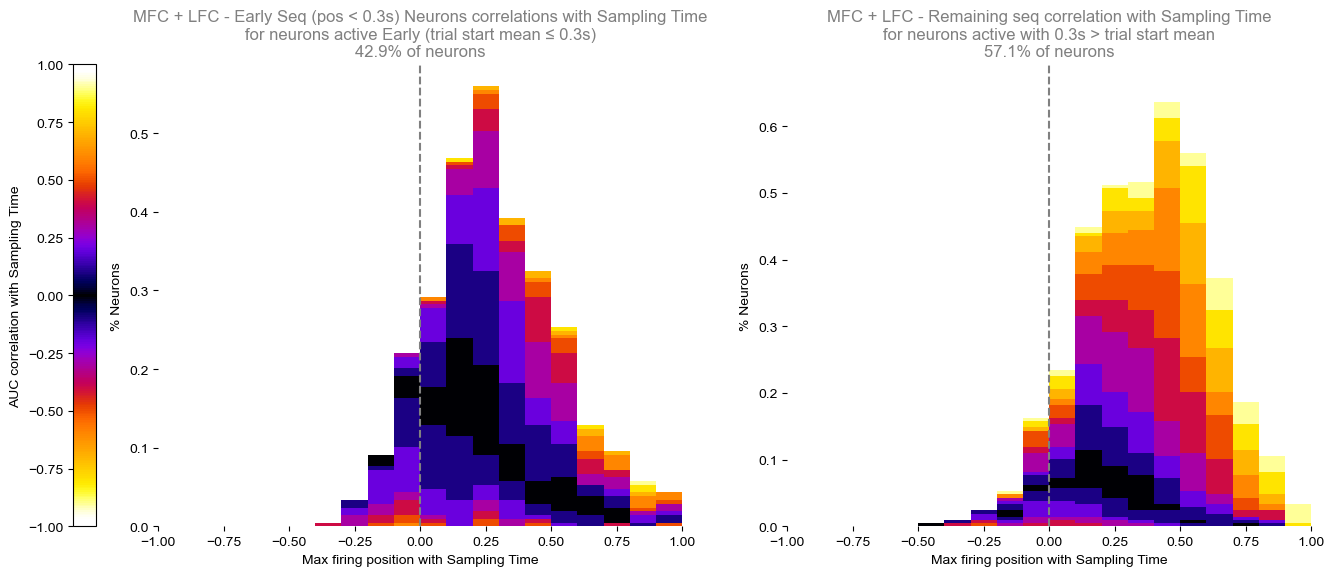

In [36]:
from .twop.rtcorrhists import plotCorrJointHist

plotCorrJointHist(res_corr_df, filter_key="zscore_filter_", time_offset=.3,
                  res_shuffle_df=res_shuffle_df, incld_std=False,
                  plot_3d=False, combine_br=True,
                  save_figs=SAVE_FIGS, fig_save_prefix=fig_save_prefix)

### Correlation Hists

Brain Region: ALM
Early seq amplitude Corr (real) above correlation threshold prcnt = 15.11%
Early seq amplitude Corr (shuffled) above correlation threshold prcnt = 4.51%
                                                                  std = 0.78%
Remaining seq amplitude Corr (real) above correlation threshold prcnt = 36.12%
Remaining seq amplitude Corr (shuffled) above correlation threshold prcnt = 6.58%
                                                                      std = 0.93%
Remaining seq firing pos Corr (real) above correlation threshold prcnt = 45.98%
Remaining seq firing pos Corr (shuffled) above correlation threshold prcnt = 6.47%
                                                                       std = 0.92%
Brain Region: M2
Early seq amplitude Corr (real) above correlation threshold prcnt = 12.66%
Early seq amplitude Corr (shuffled) above correlation threshold prcnt = 5.38%
                                                                  std = 0.71%
Remaining seq 

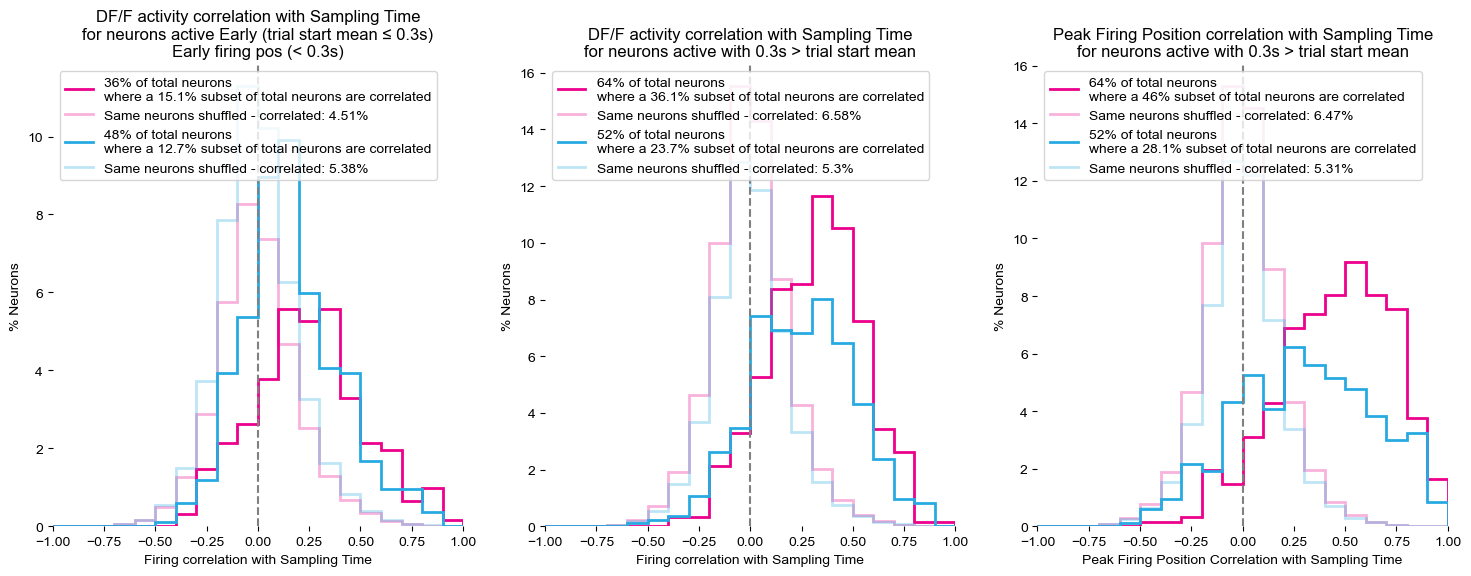

,BrainRegion,ShortName,trace_id,no_filter_firing_pos_pearson_corr,no_filter_firing_pos_pearson_pval,no_filter_firing_pos_slope,no_filter_amplitude_firing_pearson_corr,no_filter_amplitude_firing_pearson_pval,no_filter_amplitude_firing_slope,no_filter_start_max_firing_pos_mean,...,zscore_filter_amplitude_firing_pearson_pval,zscore_filter_amplitude_firing_slope,zscore_filter_start_max_firing_pos_mean,zscore_filter_start_max_firing_pos_std,zscore_filter_start_max_firing_median,zscore_filter_start_max_firing_iqr,zscore_filter_end_max_firing_pos_mean,zscore_filter_end_max_firing_pos_std,zscore_filter_end_max_firing_median,zscore_filter_end_max_firing_iqr
0,6,GP4_23_s6_L50_D250_ALM,0,0.616299,1.441893e-02,16.700363,0.562039,2.921024e-02,85.819874,0.465856,...,8.265262e-01,-79.014813,0.408795,0.325982,0.382642,0.399427,0.306820,0.329377,0.137673,0.390066
1,6,GP4_23_s6_L50_D250_ALM,2,0.606597,3.800297e-04,39.154662,0.755832,1.368271e-06,88.364674,-0.031210,...,5.124006e-03,87.187225,-0.043759,0.167637,-0.100000,0.033286,0.764355,0.145061,0.769000,0.122586
2,6,GP4_23_s6_L50_D250_ALM,3,0.038987,9.042485e-01,6.343214,0.129141,6.891535e-01,82.255512,-0.014012,...,6.891535e-01,82.255512,-0.014012,0.246427,-0.100000,0.033286,0.721654,0.257944,0.755457,0.121239
3,6,GP4_23_s6_L50_D250_ALM,4,0.635184,6.148398e-03,23.344715,0.836226,2.885229e-05,82.527974,0.608788,...,6.310856e-01,-66.540635,0.536588,0.395128,0.632284,0.549213,0.289931,0.399366,0.210474,0.478513
4,6,GP4_23_s6_L50_D250_ALM,5,-0.002372,9.799312e-01,-0.098475,0.132315,1.586504e-01,80.849504,0.667017,...,8.744506e-07,88.532919,0.673745,0.217596,0.682212,0.199714,0.132403,0.191124,0.079452,0.119896
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1441,15,GP4_85_s3_L70_D250_mm2,235,0.759788,7.434807e-33,25.763721,0.483050,3.320957e-11,86.819700,0.930071,...,1.779272e-08,87.090880,0.914610,0.275791,0.848640,0.332856,0.200801,0.249969,0.115746,0.245306
1442,15,GP4_85_s3_L70_D250_mm2,278,0.653167,6.475283e-08,21.250456,0.418546,1.472250e-03,84.149897,0.689172,...,1.860518e-02,82.848376,0.671117,0.162262,0.648927,0.199714,0.397029,0.267591,0.270573,0.365067
1443,15,GP4_85_s3_L70_D250_mm2,379,0.081475,6.862149e-01,1.334345,0.056033,7.813222e-01,35.887317,0.305591,...,4.798368e-01,68.535159,0.298147,0.080703,0.299427,0.066571,0.692914,0.268217,0.618951,0.354039
1444,15,GP4_85_s3_L70_D250_mm2,391,0.553604,2.431881e-13,20.591083,0.551369,3.170222e-13,88.754201,1.087560,...,1.734101e-10,88.833441,1.087712,0.314437,0.998426,0.432713,0.016498,0.274360,-0.059547,0.032151


In [56]:
from .twop.rtcorrhists import plotCorrDistributions

CORR_THRESH = .3
corr_thresh_df = plotCorrDistributions(res_corr_df, res_shuffle_df=res_shuffle_df,
                                       filter_key="zscore_filter_", time_offset=.3,
                                       corr_thresh=CORR_THRESH,
                                       incld_std=False, save_figs=SAVE_FIGS,
                                       fig_save_prefix=fig_save_prefix)
res_corr_df

### Pie-Chart for rigid/streteching neurons

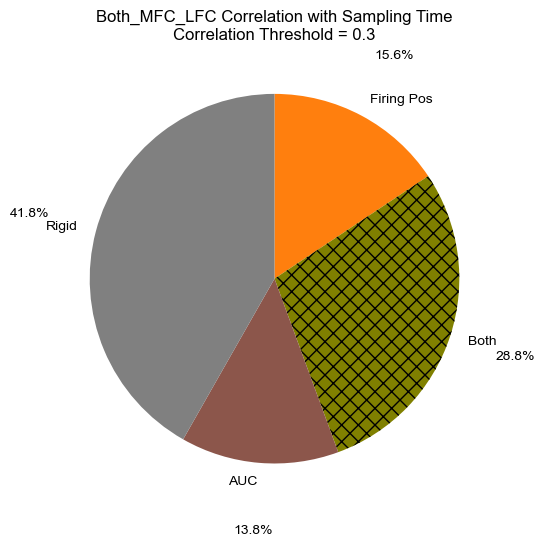

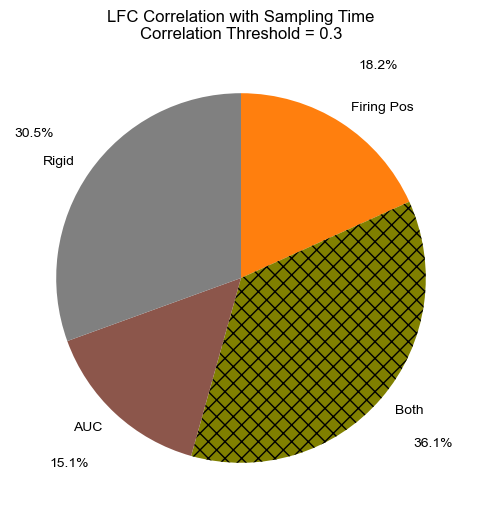

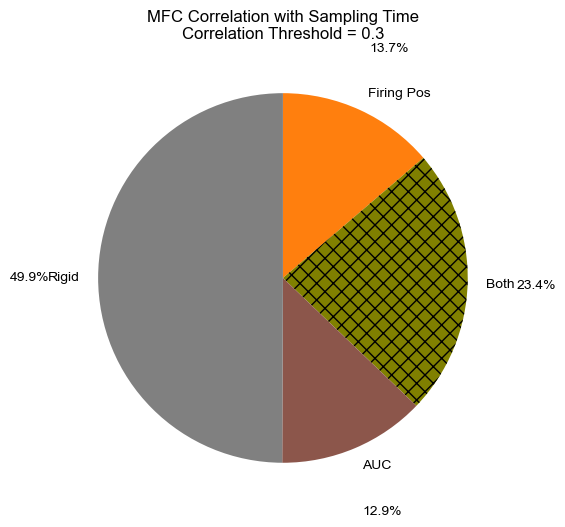

In [57]:
from .twop.rtcorrpies import plotCorrThreshPieChart

plotCorrThreshPieChart(res_corr_df, filter_key="zscore_filter_",
                       corr_thresh=CORR_THRESH, save_figs=SAVE_FIGS,
                       fig_save_prefix=fig_save_prefix)

Has early seq: True
Save fp= ../results/2P//rt_corr_Amplitude_for Early Seq_above_0.3.svg


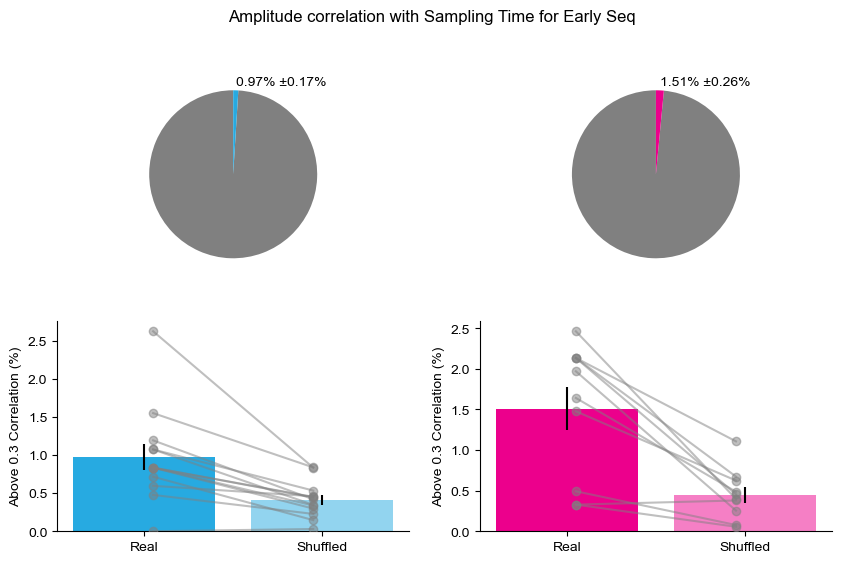

Save fp= ../results/2P//rt_corr_Amplitude_for Remaining Seq_above_0.3.svg


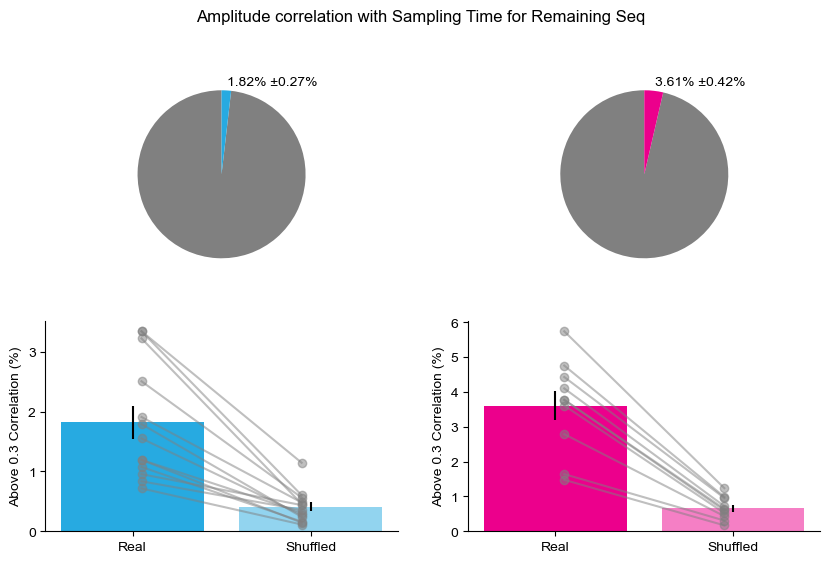

Save fp= ../results/2P//rt_corr_Firing Position_for Remaining Seq_above_0.3.svg


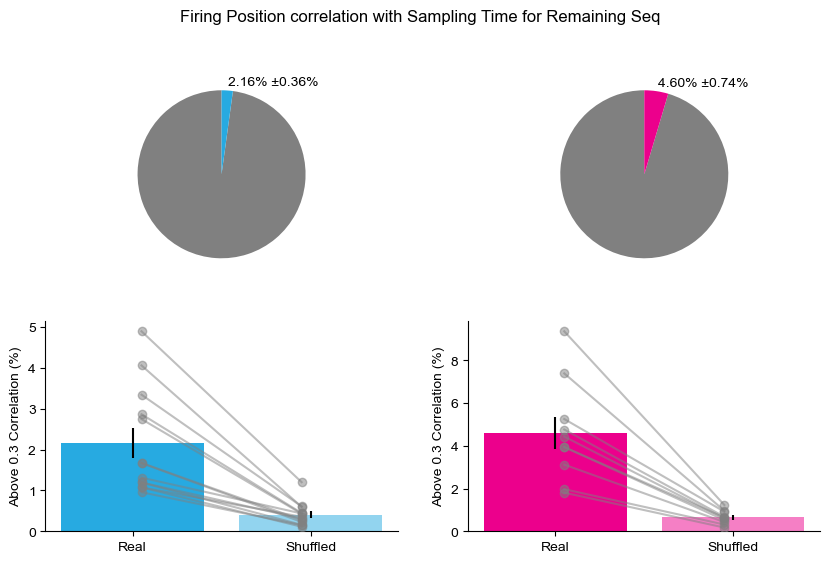

In [39]:
# The notebook used to redefine plotCorrThreshPieChart here with different
# arguments; the two panels are named apart in twop/rtcorrpies.py.
from .twop.rtcorrpies import plotCorrThreshRealVsShuffled

plotCorrThreshRealVsShuffled(corr_thresh_df, save_figs=SAVE_FIGS,
                             corr_thresh=CORR_THRESH,
                             fig_save_prefix=fig_save_prefix)

#### MFC vs LFC bars at the same correlation threshold

The pie charts above pool every neuron of a region into one wedge. Here the
same threshold crossing is computed **per session**, so each session gives one
percentage and MFC can be compared against LFC with sessions as the independent
unit (bars = mean across sessions ± SEM, dots = the individual sessions).

Three panels, all at `CORR_THRESH` on `|r|`:

1. **AUC + Firing Pos** — neurons above threshold on *either* metric (the
   union), i.e. everything that is not `Rigid` in the pie chart.
2. **AUC** — above threshold on amplitude/AUC, **including** the `Both` neurons.
3. **Firing Pos** — above threshold on firing position, **including** `Both`.

MFC and LFC are different sessions, so the comparison is unpaired: Shapiro-Wilk
on each region's per-session percentages picks the test — Welch's t-test when
both look normal, otherwise Mann-Whitney U — and both are two-sided.

,category,n_MFC,MFC_mean,MFC_sem,shapiro_W_MFC,shapiro_p_MFC,n_LFC,LFC_mean,LFC_sem,shapiro_W_LFC,shapiro_p_LFC,normality,normal,test,statistic,p_value,sig
0,AUC + Firing Pos,13,51.2613,2.9319,0.9428,0.4943,10,70.0752,4.6043,0.8235,0.0279,Shapiro-Wilk,False,Mann-Whitney U,19.5000,0.0052,**
1,AUC,13,38.9888,3.5805,0.9106,0.1870,10,53.3676,4.1646,0.8553,0.0671,Shapiro-Wilk,True,Welch t-test,-2.6181,0.0168,*
2,Firing Pos,13,37.4462,2.6886,0.9640,0.8143,10,53.9229,3.5340,0.9035,0.2390,Shapiro-Wilk,True,Welch t-test,-3.7106,0.0016,**


Save fp= ..\results\2P\rt_corr_regions_bars_above_0.3.pdf


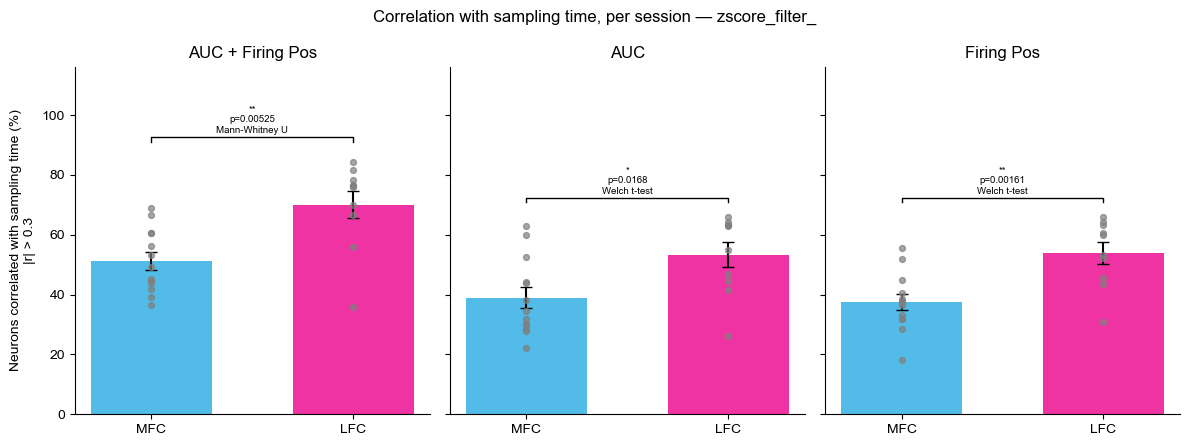

In [55]:
from .twop.plot import corrthreshregions as ctr

# Same inputs as the pie chart above: res_corr_df at CORR_THRESH on |r|.
corr_regions_prcnt_df = ctr.sessionCorrelatedPrcnt(
    res_corr_df, filter_key="zscore_filter_", corr_thresh=CORR_THRESH)

corr_regions_stats_df = ctr.regionSignificance(corr_regions_prcnt_df)
display(corr_regions_stats_df.round(4))

_ = ctr.plotRegionBars(corr_regions_prcnt_df, corr_regions_stats_df,
                       corr_thresh=CORR_THRESH, filter_key="zscore_filter_",
                       save_figs=SAVE_FIGS, fig_save_prefix=fig_save_prefix)

In [41]:
res_corr_df.query("iqr_filter_firing_pos_pearson_corr < -0.7 and iqr_filter_amplitude_firing_pearson_corr > 0.7")[["ShortName", "trace_id"]  + [col for col in res_corr_df.columns if "iqr" in col]]

,ShortName,trace_id,no_filter_start_max_firing_iqr,no_filter_end_max_firing_iqr,iqr_filter_firing_pos_pearson_corr,iqr_filter_firing_pos_pearson_pval,iqr_filter_firing_pos_slope,iqr_filter_amplitude_firing_pearson_corr,iqr_filter_amplitude_firing_pearson_pval,iqr_filter_amplitude_firing_slope,iqr_filter_start_max_firing_pos_mean,iqr_filter_start_max_firing_pos_std,iqr_filter_start_max_firing_median,iqr_filter_start_max_firing_iqr,iqr_filter_end_max_firing_pos_mean,iqr_filter_end_max_firing_pos_std,iqr_filter_end_max_firing_median,iqr_filter_end_max_firing_iqr,zscore_filter_start_max_firing_iqr,zscore_filter_end_max_firing_iqr


## Extract neurons that fires at start of sampling

In [42]:
def startOfSamplinNeurons(df, filter_key):
    # start_mean_col, start_std_col = filter_key + "start_max_firing_pos_mean", filter_key + "start_max_firing_pos_std"
    # end_mean_col, end_std_col = filter_key + "end_max_firing_pos_mean", filter_key + "end_max_firing_pos_std"
    start_mean_col, start_std_col = filter_key + "start_max_firing_median", filter_key + "start_max_firing_iqr"
    end_mean_col, end_std_col = filter_key + "end_max_firing_median", filter_key + "end_max_firing_iqr"

    early_df = df.sort_values(by=start_mean_col).reset_index(drop=True)
    late_df = df.sort_values(by=end_mean_col).reset_index(drop=True)

    # early_df = early_df[early_df[start_mean_col] + early_df[start_std_col]
    #                     <= 0.3]
    # late_df = late_df[late_df[end_mean_col] #+ late_df[end_std_col]
    #                   <= 0.3]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
    for br, early_br_df in early_df.groupby("BrainRegion"):
        late_br_df = late_df[late_df.BrainRegion == br]
        br == BrainRegion(br)
        if br == BrainRegion.ALM_Bi:
            c = "r"
        else:
            assert br == BrainRegion.M2_Bi
            c = 'b'
        ax1.errorbar(early_br_df[start_mean_col], early_br_df.index, xerr=early_br_df[start_std_col], ls='none', marker="none",
                    c=c, lw=.5)
        ax2.errorbar(late_br_df[end_mean_col], late_br_df.index, xerr=late_br_df[end_std_col], ls='none', marker="none",
                    c=c, lw=.5)

    ax1.set_xlim(-1, 3)
    ax2.set_xlim(-1, 3)
    plt.show()
    return df

startOfSamplinNeurons(res_corr_df, filter_key="no_filter_")

,BrainRegion,ShortName,trace_id,no_filter_firing_pos_pearson_corr,no_filter_firing_pos_pearson_pval,no_filter_firing_pos_slope,no_filter_amplitude_firing_pearson_corr,no_filter_amplitude_firing_pearson_pval,no_filter_amplitude_firing_slope,no_filter_start_max_firing_pos_mean,...,zscore_filter_amplitude_firing_pearson_pval,zscore_filter_amplitude_firing_slope,zscore_filter_start_max_firing_pos_mean,zscore_filter_start_max_firing_pos_std,zscore_filter_start_max_firing_median,zscore_filter_start_max_firing_iqr,zscore_filter_end_max_firing_pos_mean,zscore_filter_end_max_firing_pos_std,zscore_filter_end_max_firing_median,zscore_filter_end_max_firing_iqr
0,6,GP4_23_s6_L50_D250_ALM,0,0.616299,1.441893e-02,16.700363,0.562039,2.921024e-02,85.819874,0.465856,...,8.265262e-01,-79.014813,0.408795,0.325982,0.382642,0.399427,0.306820,0.329377,0.137673,0.390066
1,6,GP4_23_s6_L50_D250_ALM,2,0.606597,3.800297e-04,39.154662,0.755832,1.368271e-06,88.364674,-0.031210,...,5.124006e-03,87.187225,-0.043759,0.167637,-0.100000,0.033286,0.764355,0.145061,0.769000,0.122586
2,6,GP4_23_s6_L50_D250_ALM,3,0.038987,9.042485e-01,6.343214,0.129141,6.891535e-01,82.255512,-0.014012,...,6.891535e-01,82.255512,-0.014012,0.246427,-0.100000,0.033286,0.721654,0.257944,0.755457,0.121239
3,6,GP4_23_s6_L50_D250_ALM,4,0.635184,6.148398e-03,23.344715,0.836226,2.885229e-05,82.527974,0.608788,...,6.310856e-01,-66.540635,0.536588,0.395128,0.632284,0.549213,0.289931,0.399366,0.210474,0.478513
4,6,GP4_23_s6_L50_D250_ALM,5,-0.002372,9.799312e-01,-0.098475,0.132315,1.586504e-01,80.849504,0.667017,...,8.744506e-07,88.532919,0.673745,0.217596,0.682212,0.199714,0.132403,0.191124,0.079452,0.119896
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1441,15,GP4_85_s3_L70_D250_mm2,235,0.759788,7.434807e-33,25.763721,0.483050,3.320957e-11,86.819700,0.930071,...,1.779272e-08,87.090880,0.914610,0.275791,0.848640,0.332856,0.200801,0.249969,0.115746,0.245306
1442,15,GP4_85_s3_L70_D250_mm2,278,0.653167,6.475283e-08,21.250456,0.418546,1.472250e-03,84.149897,0.689172,...,1.860518e-02,82.848376,0.671117,0.162262,0.648927,0.199714,0.397029,0.267591,0.270573,0.365067
1443,15,GP4_85_s3_L70_D250_mm2,379,0.081475,6.862149e-01,1.334345,0.056033,7.813222e-01,35.887317,0.305591,...,4.798368e-01,68.535159,0.298147,0.080703,0.299427,0.066571,0.692914,0.268217,0.618951,0.354039
1444,15,GP4_85_s3_L70_D250_mm2,391,0.553604,2.431881e-13,20.591083,0.551369,3.170222e-13,88.754201,1.087560,...,1.734101e-10,88.833441,1.087712,0.314437,0.998426,0.432713,0.016498,0.274360,-0.059547,0.032151


In [43]:
active_traces_max_df

,BrainRegion,ShortName,TrialNumber,trial_dur_sec,trace_id,ChoiceCorrect,DVstr,is_active,max_pos_sec,max_amplitude,auc,trace,smoothed1_max_pos_sec,smoothed1_max_amplitude,smoothed1_auc,smoothed1_trace,smoothed2_max_pos_sec,smoothed2_max_amplitude,smoothed2_auc,smoothed2_trace
0,6,GP4_23_s6_L50_D250_ALM,192,0.3664,0,0.0,Easy,True,0.332856,2.462641,15.744971,"[0.51277447, 0.53290206, 0.49896213, 0.7788256...",0.332856,2.414907,16.753380,"[0.51819795, 0.5371643, 0.6313519, 0.91826695,...",0.332856,2.319935,17.285219,"[0.57319134, 0.6671761, 0.8255802, 1.0837845, ..."
1,6,GP4_23_s6_L50_D250_ALM,203,0.5455,0,1.0,Med,True,0.698998,2.972065,9.003000,"[0.32423505, 0.3549841, 0.11653137, -0.0770710...",0.698998,2.768578,7.865443,"[0.3186409, 0.26496533, 0.13300884, 0.02888341...",0.698998,2.509033,10.464090,"[0.26803157, 0.22514938, 0.14072496, 0.1043305..."
2,6,GP4_23_s6_L50_D250_ALM,214,0.6119,0,0.0,Hard,True,0.000000,2.950511,8.235941,"[2.9505107, 2.4052296, 1.7818356, 1.8831892, 2...",0.765569,2.759050,4.452012,"[2.7506893, 2.3588855, 2.065764, 2.0853157, 2....",0.765569,2.754528,7.456527,"[2.6249955, 2.3282244, 2.173742, 2.1358423, 2...."
3,6,GP4_23_s6_L50_D250_ALM,220,3.6777,0,1.0,Med,True,1.930566,6.199377,31.131123,"[2.5048938, 2.8712983, 3.2830174, 3.6118076, 3...",1.397996,6.041039,31.099556,"[2.6406417, 2.9264252, 3.2507787, 3.5458581, 3...",1.364711,5.924237,59.389626,"[2.78587, 3.0679946, 3.3000503, 3.4913056, 3.6..."
4,6,GP4_23_s6_L50_D250_ALM,265,0.6542,0,1.0,Easy,True,0.665712,5.551650,20.446945,"[1.5324811, 1.32962, 1.0489956, 0.9113089, 1.2...",0.665712,5.491786,66.239952,"[1.4545041, 1.2880806, 1.126074, 1.1180093, 1....",0.632427,5.367604,62.634995,"[1.3968679, 1.2906818, 1.2730134, 1.3860983, 1..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70104,15,GP4_85_s3_L70_D250_mm2,238,1.2501,439,1.0,Hard,True,0.232999,1.342311,3.056489,"[0.688798, 0.8467255, 1.1185787, 1.1779803, 1....",0.232999,1.279465,1.881477,"[0.75243485, 0.8931835, 1.0410482, 1.1121949, ...",0.232999,1.194483,3.158188,"[0.8155478, 0.93245375, 1.0267448, 1.0749433, ..."
70105,15,GP4_85_s3_L70_D250_mm2,243,1.1570,439,1.0,Med,True,0.166428,1.022029,2.353578,"[0.76404446, 0.6357362, 0.5855517, 0.677426, 0...",0.166428,0.933024,1.613388,"[0.7229929, 0.65804935, 0.6477366, 0.72339624,...",0.199714,0.869451,1.624456,"[0.7201769, 0.6841707, 0.70856774, 0.7616928, ..."
70106,15,GP4_85_s3_L70_D250_mm2,246,0.6937,439,1.0,Med,True,0.232999,1.913790,4.149842,"[0.29843885, 0.43806282, 0.8769734, 1.1866558,...",0.232999,1.545570,6.080915,"[0.36749724, 0.553701, 0.824499, 1.0244876, 1....",0.232999,1.279062,4.676562,"[0.4801253, 0.64811534, 0.8373465, 0.9720628, ..."
70107,15,GP4_85_s3_L70_D250_mm2,250,1.2976,439,1.0,Med,True,0.232999,1.061507,6.750566,"[0.22528976, 0.2218684, 0.41109356, 0.6560682,...",0.232999,0.992534,5.512491,"[0.23648274, 0.29468232, 0.4391174, 0.6278129,...",0.232999,0.901387,4.217316,"[0.29948255, 0.37536708, 0.5048923, 0.6314348,..."


# Correlatoin between trial duration and number of active neurons

In [44]:
# Moved to twop/activeneuroncount.py, where it is unit-tested.
from .twop.activeneuroncount import corrTrialDurActivityCommon

### Active Early

In [45]:
START_SAMPLING_CUTOFF = .3
early_active_df = corrTrialDurActivityCommon(active_traces_max_df,
                                             cut_before=TIME_BEFORE_SAMPLING,
                                             cut_before_how="FIX",
                                             cut_after=START_SAMPLING_CUTOFF,
                                             cut_after_how="FIX",
                                             cut_from="START",
                                             key_prefix=KEY_PREFIX,
                                             plot_count=100)
early_active_df

,BrainRegion,ShortName,trial_number,ChoiceCorrect,DVstr,trial_dur_sec,total_count,trial_active_count,trial_start_max_active_count,trial_start_extend_active_count
0,6,GP4_23_s6_L50_D250_ALM,167,0.0,Med,0.6840,77,12,2,12
1,6,GP4_23_s6_L50_D250_ALM,168,1.0,Easy,1.1475,77,15,3,15
2,6,GP4_23_s6_L50_D250_ALM,169,1.0,Easy,0.6122,77,13,8,13
3,6,GP4_23_s6_L50_D250_ALM,170,1.0,Easy,0.7198,77,11,5,11
4,6,GP4_23_s6_L50_D250_ALM,171,0.0,Easy,0.6673,77,12,3,12
...,...,...,...,...,...,...,...,...,...,...
5313,15,GP4_85_s3_L70_D250_mm2,304,1.0,Hard,0.9414,75,11,7,11
5314,15,GP4_85_s3_L70_D250_mm2,305,1.0,Med,0.9330,75,8,5,8
5315,15,GP4_85_s3_L70_D250_mm2,306,1.0,Easy,0.8287,75,16,9,16
5316,15,GP4_85_s3_L70_D250_mm2,307,1.0,Hard,1.2931,75,16,9,16


### Active Late

In [46]:
LOOK_BACK_DUR = .3
last_active_df = corrTrialDurActivityCommon(active_traces_max_df,
                                            cut_before=LOOK_BACK_DUR,
                                            cut_before_how="PRCNT",
                                            cut_after=TIME_AFTER_MOVEMENT,
                                            cut_after_how="FIX",
                                            cut_from="END",
                                            key_prefix=KEY_PREFIX,
                                            plot_count=100)
last_active_df

,BrainRegion,ShortName,trial_number,ChoiceCorrect,DVstr,trial_dur_sec,total_count,trial_active_count,trial_end_max_active_count,trial_end_extend_active_count
0,6,GP4_23_s6_L50_D250_ALM,167,0.0,Med,0.6840,77,12,5,12
1,6,GP4_23_s6_L50_D250_ALM,168,1.0,Easy,1.1475,77,15,5,15
2,6,GP4_23_s6_L50_D250_ALM,169,1.0,Easy,0.6122,77,13,5,9
3,6,GP4_23_s6_L50_D250_ALM,170,1.0,Easy,0.7198,77,11,5,9
4,6,GP4_23_s6_L50_D250_ALM,171,0.0,Easy,0.6673,77,12,5,10
...,...,...,...,...,...,...,...,...,...,...
5313,15,GP4_85_s3_L70_D250_mm2,304,1.0,Hard,0.9414,75,11,2,9
5314,15,GP4_85_s3_L70_D250_mm2,305,1.0,Med,0.9330,75,8,2,7
5315,15,GP4_85_s3_L70_D250_mm2,306,1.0,Easy,0.8287,75,16,4,12
5316,15,GP4_85_s3_L70_D250_mm2,307,1.0,Hard,1.2931,75,16,1,14


## Plot Active Early then Late

In [47]:
# The plotting machinery for S11A/S11B now lives in
# twop/activeneuronplots.py, with tests.
from .twop.activeneuronplots import (plotEarlyActiveCount,
                                     plotLastActiveCount)

C:\Users\float\AppData\Local\Temp\ipykernel_6036\1981568323.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sess_binned_df = sess_df.groupby(cut_df)
C:\Users\float\AppData\Local\Temp\ipykernel_6036\1981568323.py:100: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sess_binned_df = sess_df.groupby(cut_df)
C:\Users\float\AppData\Local\Temp\ipykernel_6036\1981568323.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  se

Save fp= ../results/2P//rt_vs_early_active_neurons_corr.svg


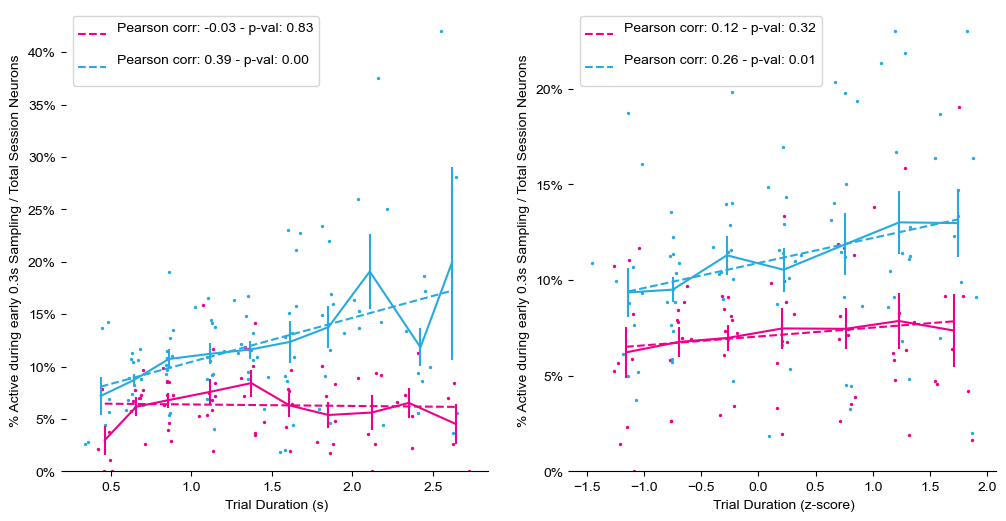

In [48]:
plotEarlyActiveCount(early_active_df[early_active_df.DVstr == "Hard"],
                     save_figs=SAVE_FIGS,
                     start_sampling_cutoff=START_SAMPLING_CUTOFF,
                     fig_save_prefix=fig_save_prefix)

C:\Users\float\AppData\Local\Temp\ipykernel_6036\1981568323.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sess_binned_df = sess_df.groupby(cut_df)
C:\Users\float\AppData\Local\Temp\ipykernel_6036\1981568323.py:100: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sess_binned_df = sess_df.groupby(cut_df)
C:\Users\float\AppData\Local\Temp\ipykernel_6036\1981568323.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  se

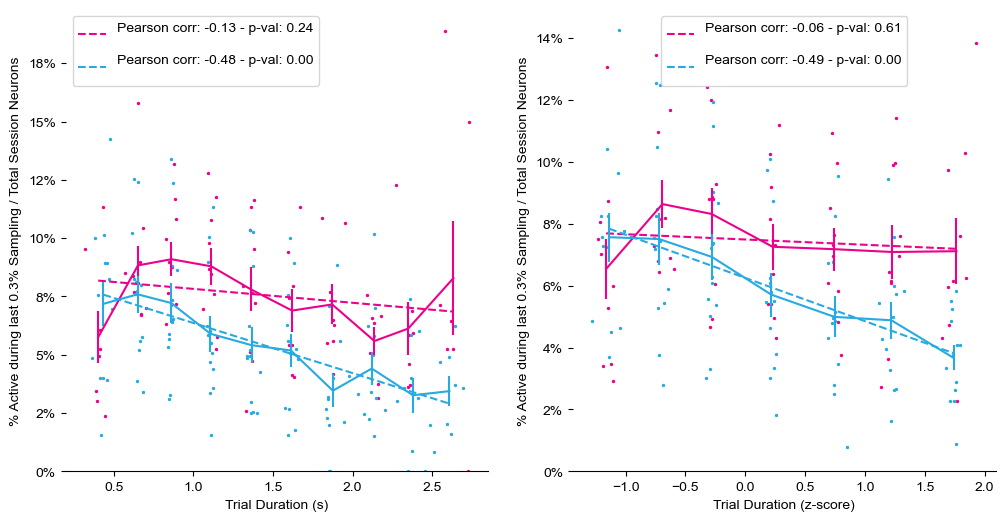

In [49]:
plotLastActiveCount(last_active_df, save_figs=SAVE_FIGS,
                    look_back_dur=LOOK_BACK_DUR,
                    fig_save_prefix=fig_save_prefix)

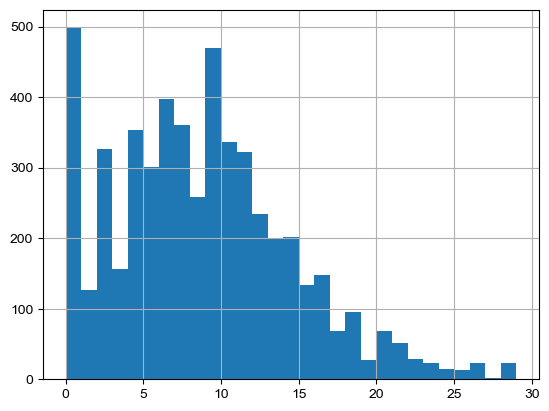

C:\Users\float\AppData\Local\Temp\ipykernel_6036\822446166.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sess_binned_df = sess_df.groupby(cut_df)
C:\Users\float\AppData\Local\Temp\ipykernel_6036\822446166.py:83: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sess_binned_df = sess_df.groupby(cut_df)
C:\Users\float\AppData\Local\Temp\ipykernel_6036\822446166.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sess_b

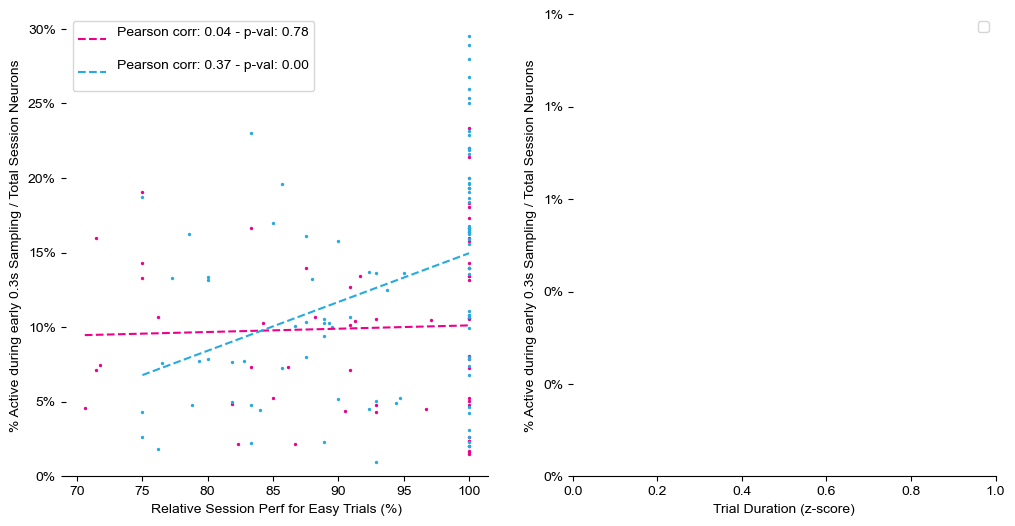

In [50]:
from .twop.activeneuronplots import plotEarlyActivePerf

plotEarlyActivePerf(early_active_df, save_figs=SAVE_FIGS,
                    start_sampling_cutoff=START_SAMPLING_CUTOFF,
                    fig_save_prefix=fig_save_prefix)

# Correlation between rt and activity on population level - Copied from PlotTraces_2, not vetted yet

In [51]:
TIME_BEFORE_SAMPLING = 0.1
TIME_AFTER_SAMPLING = 0.1 + 1/30 # Add one frame to include the last one. TODO: Fix at alignAroundEpoch()
########### Normalization is z-score in PlotTraces_2
from .twop.alignsampling import alignAroundEpoch
df_sampling_start_fixed_all = alignAroundEpoch(df_all_by_epoch.copy(), epoch="Sampling",
                                               # normalization=normalization,
                                               normalization=tracesnormalize.NormalizeZScore("neuronal"),
                                               time_before=TIME_BEFORE_SAMPLING, time_after=TIME_AFTER_SAMPLING,
                                               drop_unequal_len=True)

Processing: Split data by trial ['Name', 'Date', 'SessionNum']
Processing: Applying on full trace


  0%|          | 0/23 [00:00<?, ?it/s]

Processing: Normalized z-score of trace
Processing: Normalized z-score of trace
Processing: Normalized z-score of trace
Processing: Normalized z-score of trace
Processing: Normalized z-score of trace
Processing: Normalized z-score of trace
Processing: Normalized z-score of trace
Processing: Normalized z-score of trace
Processing: Normalized z-score of trace
Processing: Normalized z-score of trace
Processing: Normalized z-score of trace
Processing: Normalized z-score of trace
Processing: Normalized z-score of trace
Processing: Normalized z-score of trace
Processing: Normalized z-score of trace
Processing: Normalized z-score of trace
Processing: Normalized z-score of trace
Processing: Normalized z-score of trace
Processing: Normalized z-score of trace
Processing: Normalized z-score of trace
Processing: Normalized z-score of trace
Processing: Normalized z-score of trace
Processing: Normalized z-score of trace
Processing: Collapsing the dataframes back into one dataframe
Processing: Aligni

  0%|          | 0/23 [00:00<?, ?it/s]

Processing: Passing data through...


...

Processing: Split data by trial ['TrialNumber']


  0%|          | 0/23 [00:00<?, ?it/s]

Processing: Concatenated epochs of the same trial-number together


  0%|          | 0/5542 [00:00<?, ?it/s]

Processing: Collapsing the dataframes back into one dataframe


In [52]:
# from .twop.activity_correlation import getTrialsMeanActivity
# # TODO: Assign DVStr and split by DV str
# sampling_mean_activity_df = getTrialsMeanActivity(df_sampling_start_fixed_all.copy())
# sampling_mean_activity_df["calcStimulusTime"] = sampling_mean_activity_df.StimulusTime
# sampling_mean_activity_df["DVstr"] = sampling_mean_activity_df.Difficulty
# sampling_mean_activity_df["MeanActivity"] = sampling_mean_activity_df.mean_activity
# from .twop.expanddf import expandDfUngrouped
# sampling_mean_activity_df = expandDfUngrouped(df_sampling_start_fixed_all.query("EarlyWithdrawal == 0 and calcStimulusTime >= MinSample").copy(), add_raw_data=False)

In [53]:
df_sampling_start_fixed_all_sum = sumActivity(df_sampling_start_fixed_all,
                                              mean_or_sum="mean")

NameError: name 'sumActivity' is not defined

In [ ]:
from .twop.expanddf import expandDfUngrouped
if "PrevOutcomeCount" not in df_sampling_start_fixed_all_sum.columns:
    df_sampling_start_fixed_all_sum["PrevOutcomeCount"] = 0
    df_sampling_start_fixed_all_sum["SamplingType"] = "FreeSampling"
sampling_mean_activity_df = expandDfUngrouped(df_sampling_start_fixed_all_sum,
                                              add_raw_data=False)

  0%|          | 0/23 [00:00<?, ?it/s]

In [ ]:
sampling_mean_activity_df[sampling_mean_activity_df.calcStimulusTime.isnull()]

,trace_id,ShortName,Name,Date,SessionNum,BrainRegion,Layer,MeanActivity,ChoiceCorrect,ChoiceLeft,...,Difficulty3,PrevChoiceCorrect,PrevChoiceLeft,PrevOutcomeCount,calcStimulusTime,SamplingType,SessPerformance,epochs_names,epochs_ranges,TrialNumber


In [ ]:
import matplotlib.pyplot as plt
from  scipy import stats
def plotCorr(df, epoch, bin_time, bin_time_q, bin_time_qcount, corr_with_perf, zscored_time,
             save_figs):
    assert not (bin_time and bin_time_q), "Either bin time or bin quantiles"
    from .common.clr import BrainRegion as BRClr
    df = df[df.BrainRegion.isin([BrainRegion.ALM_Bi, BrainRegion.M2_Bi])]
    df = df[df.Layer == "L23"]
    df = df[df.calcStimulusTime.notnull()]
    org_len = len(df)
    MIN_ST_TIME = 0.3#5
    df = df[df.calcStimulusTime >= MIN_ST_TIME]
    # df = df[df.StimulusTime <= 2.5]
    MAX_ST_TIME = 3 # 4.9
    df = df[df.calcStimulusTime <= MAX_ST_TIME]
    st_col = "zStimulusTime" if zscored_time else "calcStimulusTime"
    df["zStimulusTime"] = df.groupby(["ShortName", "DVstr"]).calcStimulusTime.transform(stats.zscore)
    ##
    # df = df[-1 < df.zStimulusTime]
    # df = df[df.zStimulusTime < 3]
    ##
    new_len = len(df)
    ratio_used = 100*new_len/org_len
    print(f"Using: {ratio_used:.2f}%")
    fig, ax = plt.subplots(figsize=(8, 8))
    bins = np.arange(-10, 10.1, .2) if zscored_time else np.arange(0, 5.1, 0.1)
    for br, br_df in df.groupby("BrainRegion"):
        color = BRClr[br]
        br_str = str(BrainRegion(br)).split("_")[0]
        # if corr_with_perf:
        #     br_df = br_df[br_df.DVstr == "Easy"]
        if bin_time or bin_time_q:
            if bin_time:
                cut = pd.cut(br_df[st_col], bins=bins)
            else:
                br_df = br_df.sort_values(st_col).reset_index(drop=True)
                num_bins = int(round(len(br_df)/bin_time_qcount))
                cut = pd.qcut(br_df[st_col], num_bins)
                # cut = br_df.index // 50

            # print("columns", df.columns)
            br_df = br_df.groupby(cut).agg({
                "ChoiceCorrect":"mean",
                "calcStimulusTime":"mean",
                "zStimulusTime":"mean",
                "MeanActivity":"mean",
                "TrialNumber":"count", # Hack to get the number of items
            })
            br_df = br_df[br_df.TrialNumber >= bin_time_qcount]
            display(br_df)
        br_df = br_df[br_df[st_col].notnull()]
        x_col = "ChoiceCorrect" if corr_with_perf else st_col
        if corr_with_perf:
            br_df[x_col] *= 100
        x = br_df[x_col]
        y = br_df.MeanActivity
        ax.scatter(x, y, color=color, s=5)
        # lin_reg = stats.linregress(br_df.calcStimulusTime, br_df.MeanActivity)
        # print("xs:", x)
        # print("ys:", y)
        lin_reg = stats.linregress(x, y)
        x = [br_df[x_col].min(), br_df[x_col].max()]
        print(br_str, "Mean activity:", list(y))
        print(br_str, "Stimulus Time:", list(br_df["calcStimulusTime"]))
        print(br_str, "Count:", list(br_df["TrialNumber"]))
        y = [lin_reg.intercept + x[0]*lin_reg.slope,
             lin_reg.intercept + x[1]*lin_reg.slope]
        ax.plot(x, y, c=color, label=f"{br_str} r={lin_reg.rvalue:.3f} - "
                                     f"p={lin_reg.pvalue:.3f} - Slope: {lin_reg.slope:.3f}")
    ax.legend(loc="upper left")
    # ax.set_ylim(-0.05, 0.25)
    # ax.set_xlim(-2, 2)
    if corr_with_perf:
        ax.set_xlim(45, 100)
        ax.axvline(50, color="gray", ls="--", dashes=(3, 10))
    ax.set_ylabel("z-scored Mean Population Activity")
    ax.set_xlabel("Mean Performance" if corr_with_perf else
                  ("Z-Scored" if zscored_time else '') + "Sampling Duration (s)")
    [ax.spines[_dir].set_visible(False) for _dir in ["top", "right", "bottom", "left"]]
    title = f"Average population activity during {epoch}\n"
    if zscored_time:
        title += "(ZScored-time) "
    if bin_time:
        title += "Time-binned"
    elif bin_time_q:
        title += f"Time #Q-bins={bin_time_qcount}"
    ax.set_title(title)
    if save_figs:
        save_fp = f"{fig_save_prefix}/correlation/corrr_2p_population_vs_{x_col}_"
        if bin_time:
            save_fp += "time_binned"
        elif bin_time_q:
            save_fp += f"time_q_binned={bin_time_qcount}"
        else:
            "single_trials"
        if zscored_time:
             save_fp += "_zscored_time"
        save_fp += f"_min_st={MIN_ST_TIME}_max_st={MAX_ST_TIME}_"
        save_fp += f"traces_start_{TIME_BEFORE_SAMPLING}s_"
        save_fp += f"before_sampling_and_{TIME_AFTER_SAMPLING}s_after"
        save_fp += f".svg"
        plt.savefig(save_fp, dpi=300)
    plt.show()


def loopPlotCorr():
    for bin_time, bin_time_q in [(False, False),
                                 (True, False),
                                 (False, True)
                                 ]:
        for z_score_time in [True,
                             #False
                             ]:
            for corr_with_perf in [True,
                                   False
                                   ]:
                plotCorr(sampling_mean_activity_df.copy(), epoch="start of sampling", corr_with_perf=corr_with_perf,
                         bin_time=bin_time, bin_time_q=bin_time_q, bin_time_qcount=50, zscored_time=z_score_time,
                         save_figs=False)

loopPlotCorr()
# plotCorr(sampling_mean_activity_df.copy(), epoch="start of sampling", corr_with_perf=False,
#          bin_time=True, bin_time_q=False, bin_time_qcount=10, zscored_time=True, save_figs=SAVE_FIGS)

Using: 96.49%
ALM Mean activity: [-0.12608538568019867, -0.016246763989329338, -0.13218969106674194, -0.017937853932380676, -0.008300662972033024, -0.160667285323143, -0.3773323893547058, -0.01257028616964817, 0.021859517320990562, 0.04763738065958023, 0.22946490347385406, 0.18379119038581848, 0.01972133293747902, -0.013524158857762814, -0.04935295134782791, 0.1040402427315712, 0.14758643507957458, 0.03805706650018692, 0.05461888387799263, 0.2779447138309479, -0.22270910441875458, -0.2709701657295227, -0.11330258101224899, -0.5307716131210327, 0.27642759680747986, 0.34580954909324646, 0.03936833143234253, -0.02413463220000267, -0.04581403732299805, 0.0006735473871231079, 0.17798838019371033, 0.18273527920246124, -0.09064070135354996, 0.05326030030846596, 0.308239221572876, 0.0652545839548111, 0.3062286376953125, 0.03770316019654274, 0.11429666727781296, -0.24677014350891113, -0.207340270280838, -0.12376948446035385, 0.08680462837219238, -0.08217086642980576, -0.02411543019115925, 0.776

Using: 96.49%
ALM Mean activity: [-0.12608538568019867, -0.016246763989329338, -0.13218969106674194, -0.017937853932380676, -0.008300662972033024, -0.160667285323143, -0.3773323893547058, -0.01257028616964817, 0.021859517320990562, 0.04763738065958023, 0.22946490347385406, 0.18379119038581848, 0.01972133293747902, -0.013524158857762814, -0.04935295134782791, 0.1040402427315712, 0.14758643507957458, 0.03805706650018692, 0.05461888387799263, 0.2779447138309479, -0.22270910441875458, -0.2709701657295227, -0.11330258101224899, -0.5307716131210327, 0.27642759680747986, 0.34580954909324646, 0.03936833143234253, -0.02413463220000267, -0.04581403732299805, 0.0006735473871231079, 0.17798838019371033, 0.18273527920246124, -0.09064070135354996, 0.05326030030846596, 0.308239221572876, 0.0652545839548111, 0.3062286376953125, 0.03770316019654274, 0.11429666727781296, -0.24677014350891113, -0.207340270280838, -0.12376948446035385, 0.08680462837219238, -0.08217086642980576, -0.02411543019115925, 0.776

Using: 96.49%


C:\Users\float\AppData\Local\Temp\ipykernel_13032\2259657994.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  br_df = br_df.groupby(cut).agg({


,ChoiceCorrect,calcStimulusTime,zStimulusTime,MeanActivity,TrialNumber
zStimulusTime,,,,,
"(-1.4, -1.2]",0.647059,0.596671,-1.295489,-0.003220,68
"(-1.2, -1.0]",0.711538,0.678414,-1.100125,0.044940,104
"(-1.0, -0.8]",0.760000,0.728481,-0.896008,0.032905,150
"(-0.8, -0.6]",0.765432,0.801939,-0.693181,0.060997,243
"(-0.6, -0.4]",0.734082,0.845020,-0.500961,0.045985,267
"(-0.4, -0.2]",0.750000,0.911111,-0.310977,0.060861,220
"(-0.2, -3.55e-14]",0.813559,1.013127,-0.108746,0.060224,236
"(-3.55e-14, 0.2]",0.780749,1.100216,0.104000,0.046735,187
"(0.2, 0.4]",0.811189,1.147003,0.304060,0.032159,143


...

,ChoiceCorrect,calcStimulusTime,zStimulusTime,MeanActivity,TrialNumber
zStimulusTime,,,,,
"(-3.689, -1.55]",0.490196,0.465265,-1.863464,-0.085974,51
"(-1.55, -1.327]",0.640000,0.568676,-1.426721,-0.062225,50
"(-1.327, -1.195]",0.660000,0.606808,-1.260820,0.008487,50
"(-1.195, -1.095]",0.666667,0.684339,-1.148894,0.048406,51
"(-1.095, -1.002]",0.760000,0.669482,-1.044474,0.035213,50
"(-1.002, -0.928]",0.720000,0.714262,-0.965043,0.008381,50
"(-0.928, -0.856]",0.820000,0.721140,-0.894492,0.027024,50
"(-0.856, -0.799]",0.745098,0.748880,-0.827910,0.062174,51
"(-0.799, -0.753]",0.740000,0.755424,-0.774643,0.049922,50


ALM Mean activity: [-0.08597366511821747, -0.062225375324487686, 0.008487040176987648, 0.048405833542346954, 0.035213302820920944, 0.008380655199289322, 0.027024192735552788, 0.06217421591281891, 0.049921512603759766, 0.0426618717610836, 0.07317651808261871, 0.08649853616952896, 0.0369400680065155, 0.0475219190120697, 0.009320707991719246, 0.12911763787269592, 0.03217751905322075, 0.01771300844848156, 0.08421287685632706, 0.046251080930233, 0.07807235419750214, 0.09505018591880798, 0.0255722738802433, 0.03597714379429817, 0.04132907837629318, 0.08239132165908813, 0.05747859925031662, 0.04243583232164383, 0.026704836636781693, 0.023960184305906296, 0.08654039353132248, 0.025616271421313286, 0.061554938554763794, 0.04475424811244011, 0.06122524291276932, 0.0035444528330117464, 0.10317429900169373, 0.06892268359661102, -0.01052337046712637, 0.06768260896205902, 0.07400665432214737, 0.08290903270244598, -0.02693753130733967, 0.0756191536784172, 0.09279017150402069, 0.057776641100645065]
AL

C:\Users\float\AppData\Local\Temp\ipykernel_13032\2259657994.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  br_df = br_df.groupby(cut).agg({


,ChoiceCorrect,calcStimulusTime,zStimulusTime,MeanActivity,TrialNumber
zStimulusTime,,,,,
"(-1.8399999999999999, -1.252]",0.470588,0.494714,-1.422089,-0.003163,51
"(-1.252, -1.153]",0.800000,0.527250,-1.198839,0.018129,50
"(-1.153, -1.099]",0.720000,0.549180,-1.125223,0.006361,50
"(-1.099, -1.05]",0.720000,0.559982,-1.075172,0.009195,50
"(-1.05, -1.001]",0.800000,0.570118,-1.025069,0.028129,50
"(-1.001, -0.969]",0.840000,0.595464,-0.986197,-0.062637,50
"(-0.969, -0.934]",0.620000,0.617792,-0.952006,0.049051,50
"(-0.934, -0.894]",0.700000,0.629216,-0.915333,0.058170,50
"(-0.894, -0.858]",0.760000,0.636772,-0.874905,0.073674,50


M2 Mean activity: [-0.0031628634314984083, 0.018129482865333557, 0.006360961124300957, 0.00919546652585268, 0.028128808364272118, -0.06263736635446548, 0.049050550907850266, 0.058169540017843246, 0.07367350161075592, 0.054211247712373734, 0.013951419852674007, 0.03383048623800278, 0.04466983675956726, 0.10567580908536911, 0.06345083564519882, 0.05621430277824402, 0.10281596332788467, 0.024699892848730087, 0.1176275759935379, 0.10866471379995346, 0.13630177080631256, 0.14805811643600464, 0.08515505492687225, 0.08492090553045273, 0.16490942239761353, 0.15100251138210297, 0.08546686172485352, 0.07142885029315948, 0.10636758804321289, 0.17020732164382935, 0.17298759520053864, 0.08056602627038956, 0.09667471796274185, 0.059495314955711365, 0.09966137260198593, 0.0800158679485321, 0.11056825518608093, 0.057413458824157715, 0.06445003300905228, 0.1268557906150818, 0.14003492891788483, 0.09718909859657288, 0.09033584594726562, 0.08626188337802887, 0.055551592260599136, 0.05033734440803528, 0.1

## Repeat but make activity the x-axis - TODO: Investigate trials where Activity doesn't correlate with Perf.

In [ ]:
import matplotlib.pyplot as plt
from  scipy import stats
def plotCorr(df, epoch, bin_time, bin_time_q, bin_time_qcount, corr_with_perf, zscored_time,
             save_figs):
    assert not (bin_time and bin_time_q), "Either bin time or bin quantiles"
    from .common.clr import BrainRegion as BRClr
    df = df[df.BrainRegion.isin([BrainRegion.ALM_Bi, BrainRegion.M2_Bi])]
    df = df[df.Layer == "L23"]
    df = df[df.calcStimulusTime.notnull()]
    org_len = len(df)
    MIN_ST_TIME = 0.3#5
    df = df[df.calcStimulusTime >= MIN_ST_TIME]
    # df = df[df.StimulusTime <= 2.5]
    MAX_ST_TIME = 3
    df = df[df.calcStimulusTime <= MAX_ST_TIME]
    st_col = "zStimulusTime" if zscored_time else "calcStimulusTime"
    df["zStimulusTime"] = df.groupby(["ShortName", "DVstr"]).calcStimulusTime.transform(stats.zscore)
    new_len = len(df)
    ratio_used = 100*new_len/org_len
    print(f"Using: {ratio_used:.2f}%")
    fig, ax = plt.subplots(figsize=(8, 8))
    bins = np.arange(-10, 10.1, 1) if zscored_time else np.arange(0, 5.1, 0.1)
    for br, br_df_ in df.groupby("BrainRegion"):
        color = BRClr[br]
        br_str = str(BrainRegion(br)).split("_")[0]
        y_col = "ChoiceCorrect" if corr_with_perf else st_col
        for sess, br_df in br_df_.groupby("ShortName"):
            #br_df = br_df[br_df[st_col].notnull()]
            agg_dict = {
                "ChoiceCorrect":"mean",
                "calcStimulusTime":"mean",
                "zStimulusTime":"mean",
                "MeanActivity":"mean",
                "TrialNumber":"count", # Hack to get the number of items
            }
            if True: #not corr_with_perf:
                assert bin_time or bin_time_q
                if corr_with_perf:
                    br_df = br_df[br_df.DVstr == "Easy"]
                # cut_li = []
                # for _, sess_trace_df in br_df.groupby("ShortName", "trace_id"):
                #     _, time_cut_bins = pd.qcut(uniq_sess_df_st, bin_time_qcount, retbins=True)
                #     #print("time_cut_bins:", time_cut_bins)
                #     cut_li.append(time_cut)
                # cut = pd.concat(cut_li)
                num_bins = int(round(len(br_df) / bin_time_qcount))
                cut = br_df.index // num_bins
                print("num bins:", num_bins, "- len:", len(br_df), " - groups:", cut.nunique())

                # print("columns", df.columns)
                br_df = br_df.groupby(pd.qcut(br_df.MeanActivity, num_bins)).agg(agg_dict)
                # br_df = br_df.groupby(cut).agg(agg_dict)
                # br_df = br_df[br_df.TrialNumber > 5]
            x = br_df.MeanActivity
            y = br_df[y_col]
            if y_col == "ChoiceCorrect":
                y *= 100
            # x = x[:-1]
            # y = y[:-1]
            # print("Y col:", y)
            ax.scatter(x, y, color=color, s=5)
            # lin_reg = stats.linregress(br_df.calcStimulusTime, br_df.MeanActivity)
            # print("xs:", x)
            # print("ys:", y)
            lin_reg = stats.linregress(x, y)
            x = [br_df.MeanActivity.min(), br_df.MeanActivity.max()]
            print(br_str, "Mean activity:", list(x))
            print(br_str, "Stimulus Time:", list(br_df["calcStimulusTime"]))
            print(br_str, "Count:", list(br_df["TrialNumber"]))
            y = [lin_reg.intercept + x[0]*lin_reg.slope,
                lin_reg.intercept + x[1]*lin_reg.slope]
            ax.plot(x, y, c=color, label=f"{br_str} r={lin_reg.rvalue:.3f} - "
                                        f"p={lin_reg.pvalue:.3f} - Slope: {lin_reg.slope:.3f}")
        # ax.legend(loc="upper left")
    # ax.set_ylim(-0.05, 0.25)
    if corr_with_perf:
        ax.set_ylim(45, 100)
        ax.axhline(50, color="gray", ls="--", dashes=(3, 10))
    ax.set_xlabel("z-scored Mean Population Activity")
    ax.set_ylabel("Mean Performance" if corr_with_perf else
                  ("Z-Scored" if zscored_time else '') + "Sampling Duration (s)")
    [ax.spines[_dir].set_visible(False) for _dir in ["top", "right", "bottom", "left"]]
    title = f"Average population activity during {epoch}\n"
    if zscored_time:
        title += "(ZScored-time) "
    if bin_time:
        title += "Time-binned"
    elif bin_time_q:
        title += f"Time #Q-bins={bin_time_qcount}"
    ax.set_title(title)
    if save_figs:
        save_fp = f"{fig_save_prefix}/corrr_2p_population_vs_{y_col}_"
        if bin_time:
            save_fp += "time_binned"
        elif bin_time_q:
            save_fp += f"time_q_binned={bin_time_qcount}"
        else:
            "single_trials"
        if zscored_time:
             save_fp += "_zscored_time"
        save_fp += f"_min_st={MIN_ST_TIME}_max_st={MAX_ST_TIME}_"
        save_fp += f"traces_start_{TIME_BEFORE_SAMPLING}s_"
        save_fp += f"before_sampling_and_{TIME_AFTER_SAMPLING}s_after"
        save_fp += f".svg"
        plt.savefig(save_fp, dpi=300)
    plt.show()


def loopPlotCorr():
    for bin_time, bin_time_q in [#(False, False),
                                 #(True, False),
                                 (False, True)
                                 ]:
        for z_score_time in [True,
                             #False
                             ]:
            for corr_with_perf in [True,
                                   False]:
                plotCorr(sampling_mean_activity_df.copy(), epoch="start of sampling", corr_with_perf=corr_with_perf,
                         bin_time=bin_time, bin_time_q=bin_time_q, bin_time_qcount=50, zscored_time=z_score_time,
                         save_figs=False)

loopPlotCorr()
# plotCorr(sampling_mean_activity_df.copy(), epoch="start of sampling", corr_with_perf=False,
#          bin_time=True, bin_time_q=False, bin_time_qcount=10, zscored_time=True, save_figs=SAVE_FIGS)

Using: 96.49%
num bins: 3 - len: 127  - groups: 69
ALM Mean activity: [np.float32(-0.31574094), np.float32(0.1826123)]
ALM Stimulus Time: [0.7510142857142857, 0.7440285714285714, 0.7635302325581396]
ALM Count: [42, 42, 43]
num bins: 3 - len: 128  - groups: 74
ALM Mean activity: [np.float32(-0.1753779), np.float32(0.3382)]
ALM Stimulus Time: [0.8842813953488371, 0.8600071428571429, 0.8654162790697674]
ALM Count: [43, 42, 43]
num bins: 2 - len: 123  - groups: 92
ALM Mean activity: [np.float32(-0.05847709), np.float32(0.27022353)]
ALM Stimulus Time: [0.7712370967741935, 0.8178147540983606]
ALM Count: [62, 61]
num bins: 2 - len: 85  - groups: 71
ALM Mean activity: [np.float32(-0.2838584), np.float32(-0.024358176)]
ALM Stimulus Time: [1.105, 1.0230738095238094]
ALM Count: [43, 42]
num bins: 2 - len: 78  - groups: 63
ALM Mean activity: [np.float32(-0.12052162), np.float32(0.19370541)]
ALM Stimulus Time: [0.9407179487179488, 1.0379871794871793]
ALM Count: [39, 39]
num bins: 2 - len: 90  - gro

C:\Users\float\AppData\Local\Temp\ipykernel_13032\2788462845.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  br_df = br_df.groupby(pd.qcut(br_df.MeanActivity, num_bins)).agg(agg_dict)
C:\Users\float\AppData\Local\Temp\ipykernel_13032\2788462845.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  br_df = br_df.groupby(pd.qcut(br_df.MeanActivity, num_bins)).agg(agg_dict)
C:\Users\float\AppData\Local\Temp\ipykernel_13032\2788462845.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or ob

Using: 96.49%
num bins: 5 - len: 226  - groups: 46
ALM Mean activity: [np.float32(-0.44371974), np.float32(0.25363988)]
ALM Stimulus Time: [0.7596065217391303, 0.7427933333333333, 0.7546622222222222, 0.7521777777777777, 0.788148888888889]
ALM Count: [46, 45, 45, 45, 45]
num bins: 5 - len: 243  - groups: 50
ALM Mean activity: [np.float32(-0.23959942), np.float32(0.46626166)]
ALM Stimulus Time: [0.8790591836734695, 0.9222104166666667, 0.9323918367346938, 0.88806875, 0.8609959183673469]
ALM Count: [49, 48, 49, 48, 49]
num bins: 5 - len: 270  - groups: 55
ALM Mean activity: [np.float32(-0.18214342), np.float32(0.42045215)]
ALM Stimulus Time: [0.7934740740740741, 0.8179185185185185, 0.8284796296296295, 0.8716462962962963, 0.8515240740740742]
ALM Count: [54, 54, 54, 54, 54]
num bins: 5 - len: 250  - groups: 52
ALM Mean activity: [np.float32(-0.3742154), np.float32(0.0840653)]
ALM Stimulus Time: [1.3269900000000001, 1.31644, 1.314338, 1.2477099999999999, 1.14609]
ALM Count: [50, 50, 50, 50, 5

C:\Users\float\AppData\Local\Temp\ipykernel_13032\2788462845.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  br_df = br_df.groupby(pd.qcut(br_df.MeanActivity, num_bins)).agg(agg_dict)
C:\Users\float\AppData\Local\Temp\ipykernel_13032\2788462845.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  br_df = br_df.groupby(pd.qcut(br_df.MeanActivity, num_bins)).agg(agg_dict)
C:\Users\float\AppData\Local\Temp\ipykernel_13032\2788462845.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or ob